<a href="https://colab.research.google.com/github/SebastianPerezCalle/SENALES-Y-SISTEMAS-2025-1/blob/main/Taller_2_SyS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Taller 2 - Sebastián Pérez Calle

##Transformada Fourier

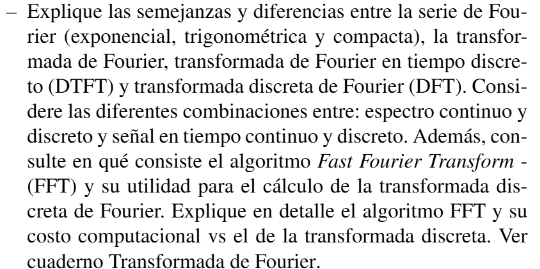

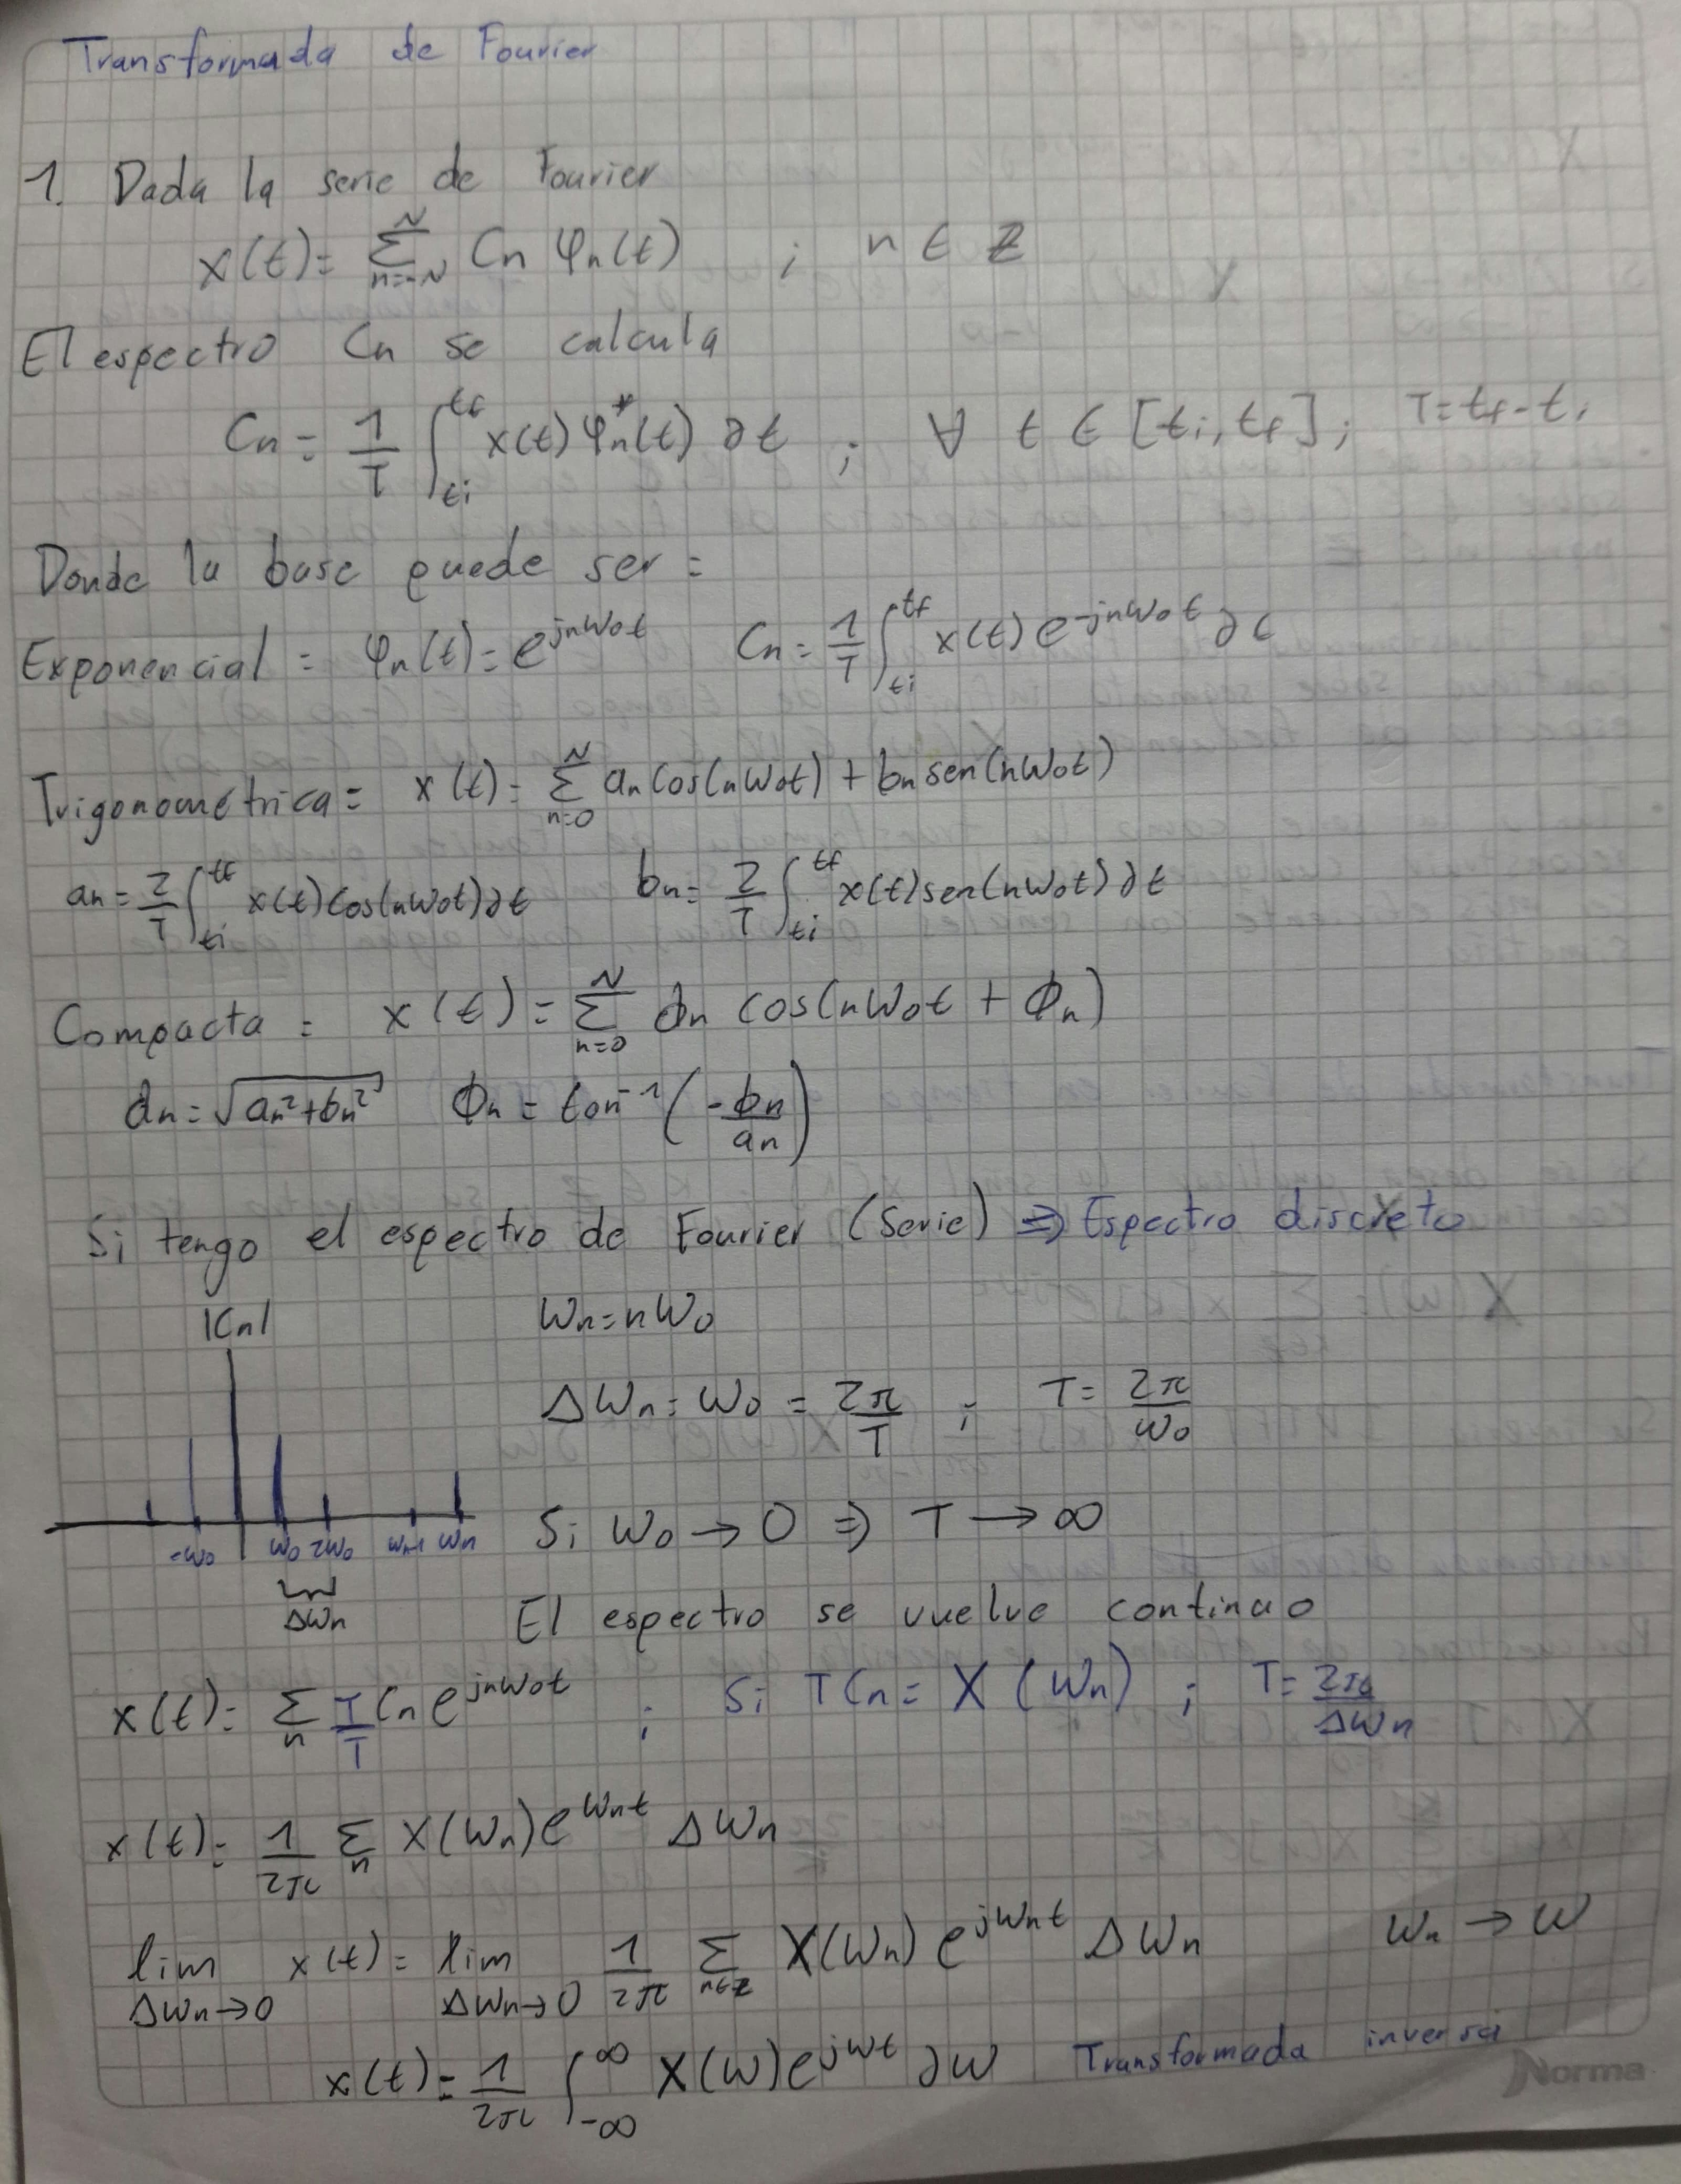

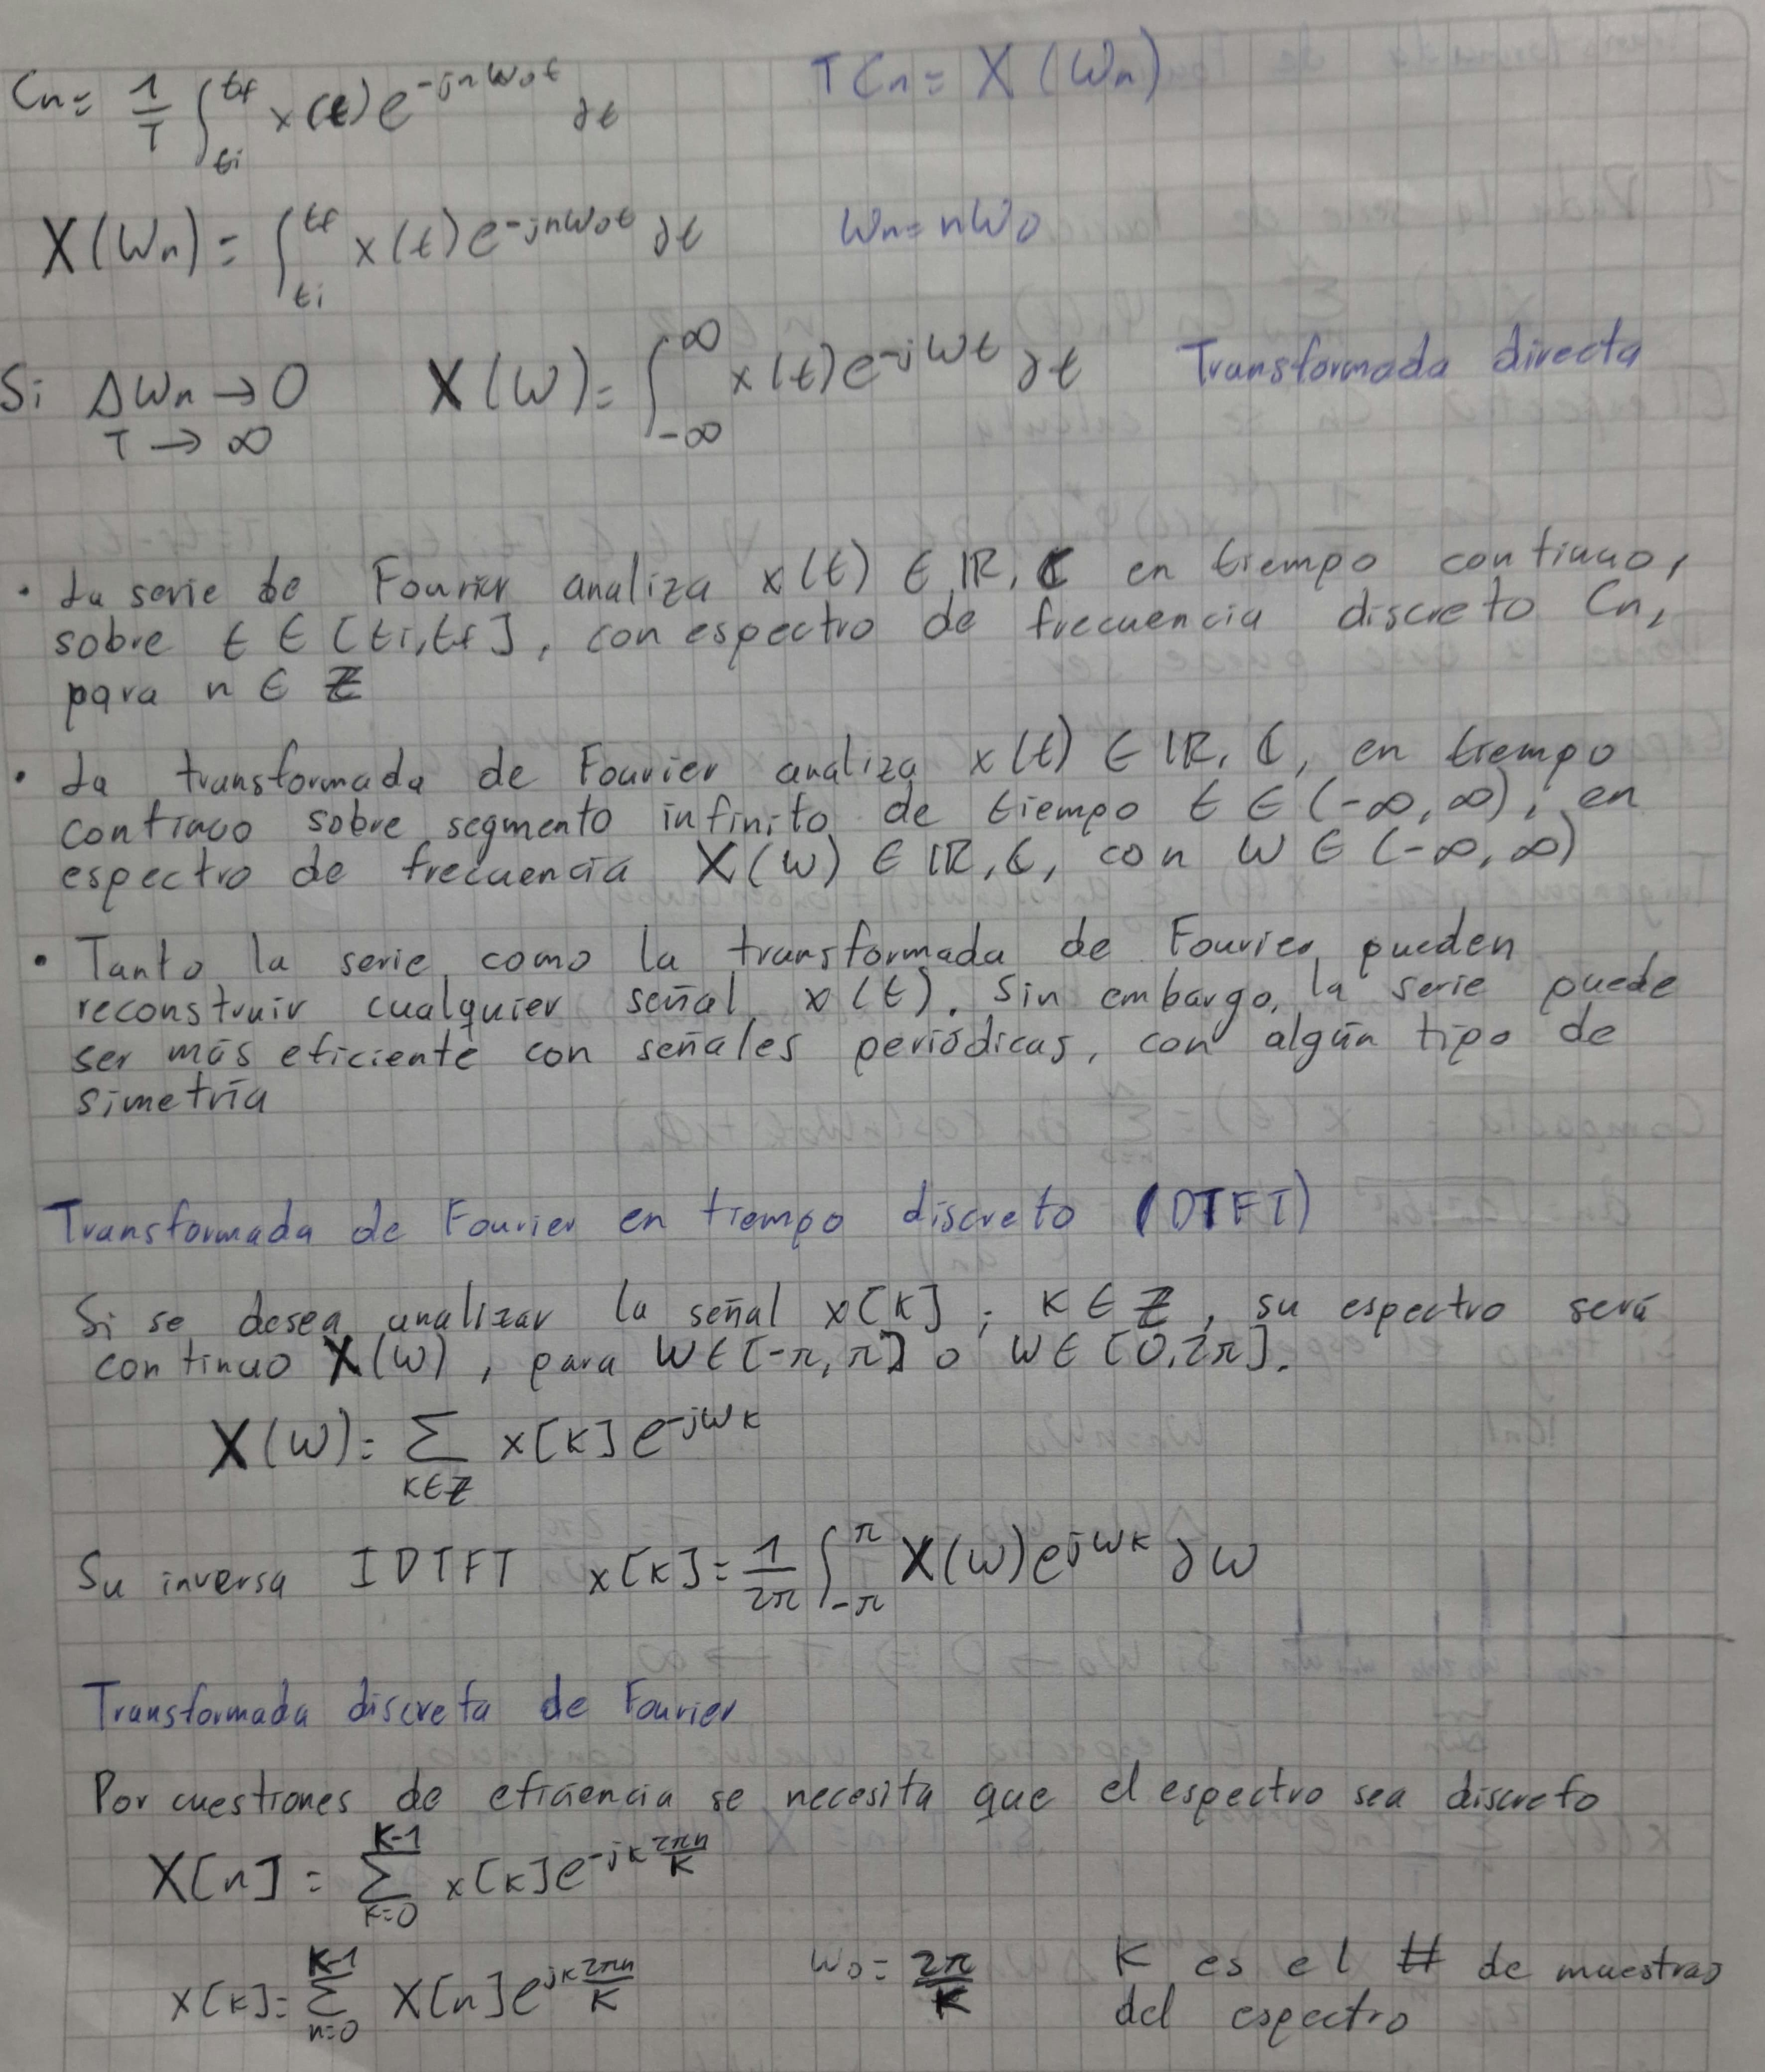

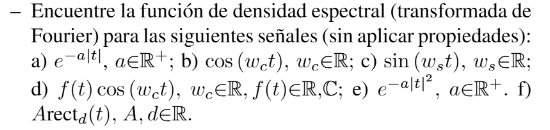

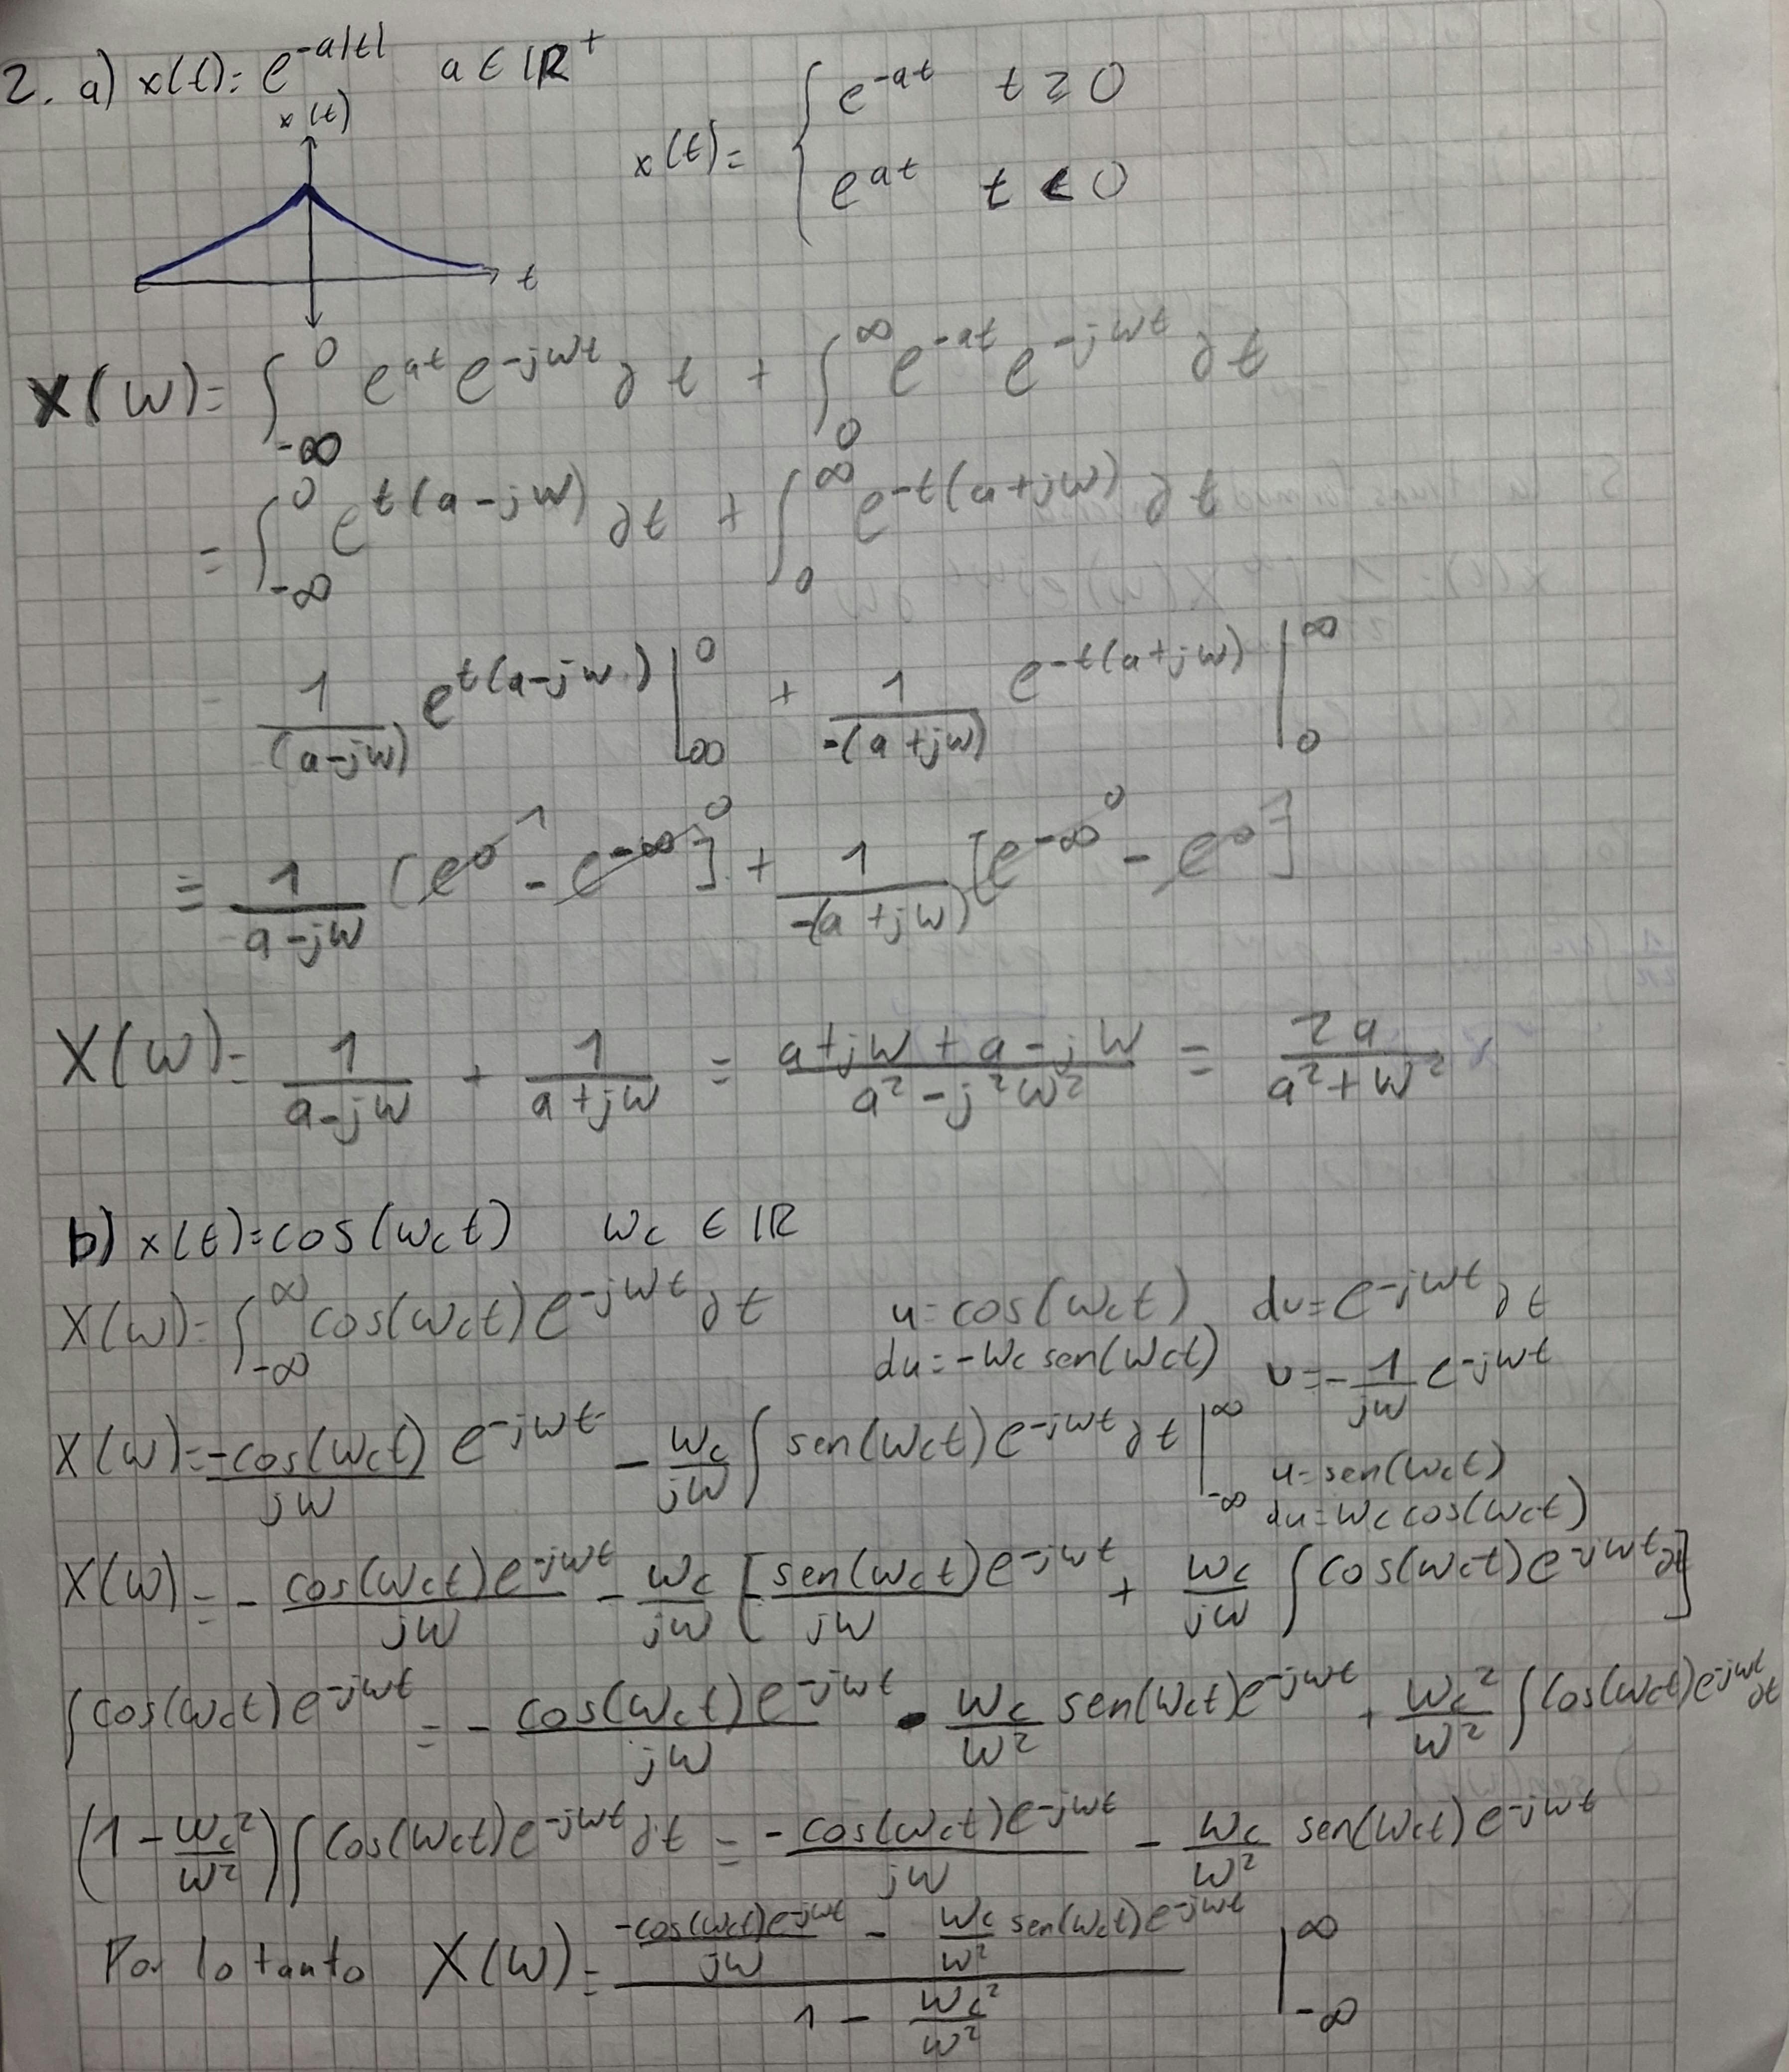

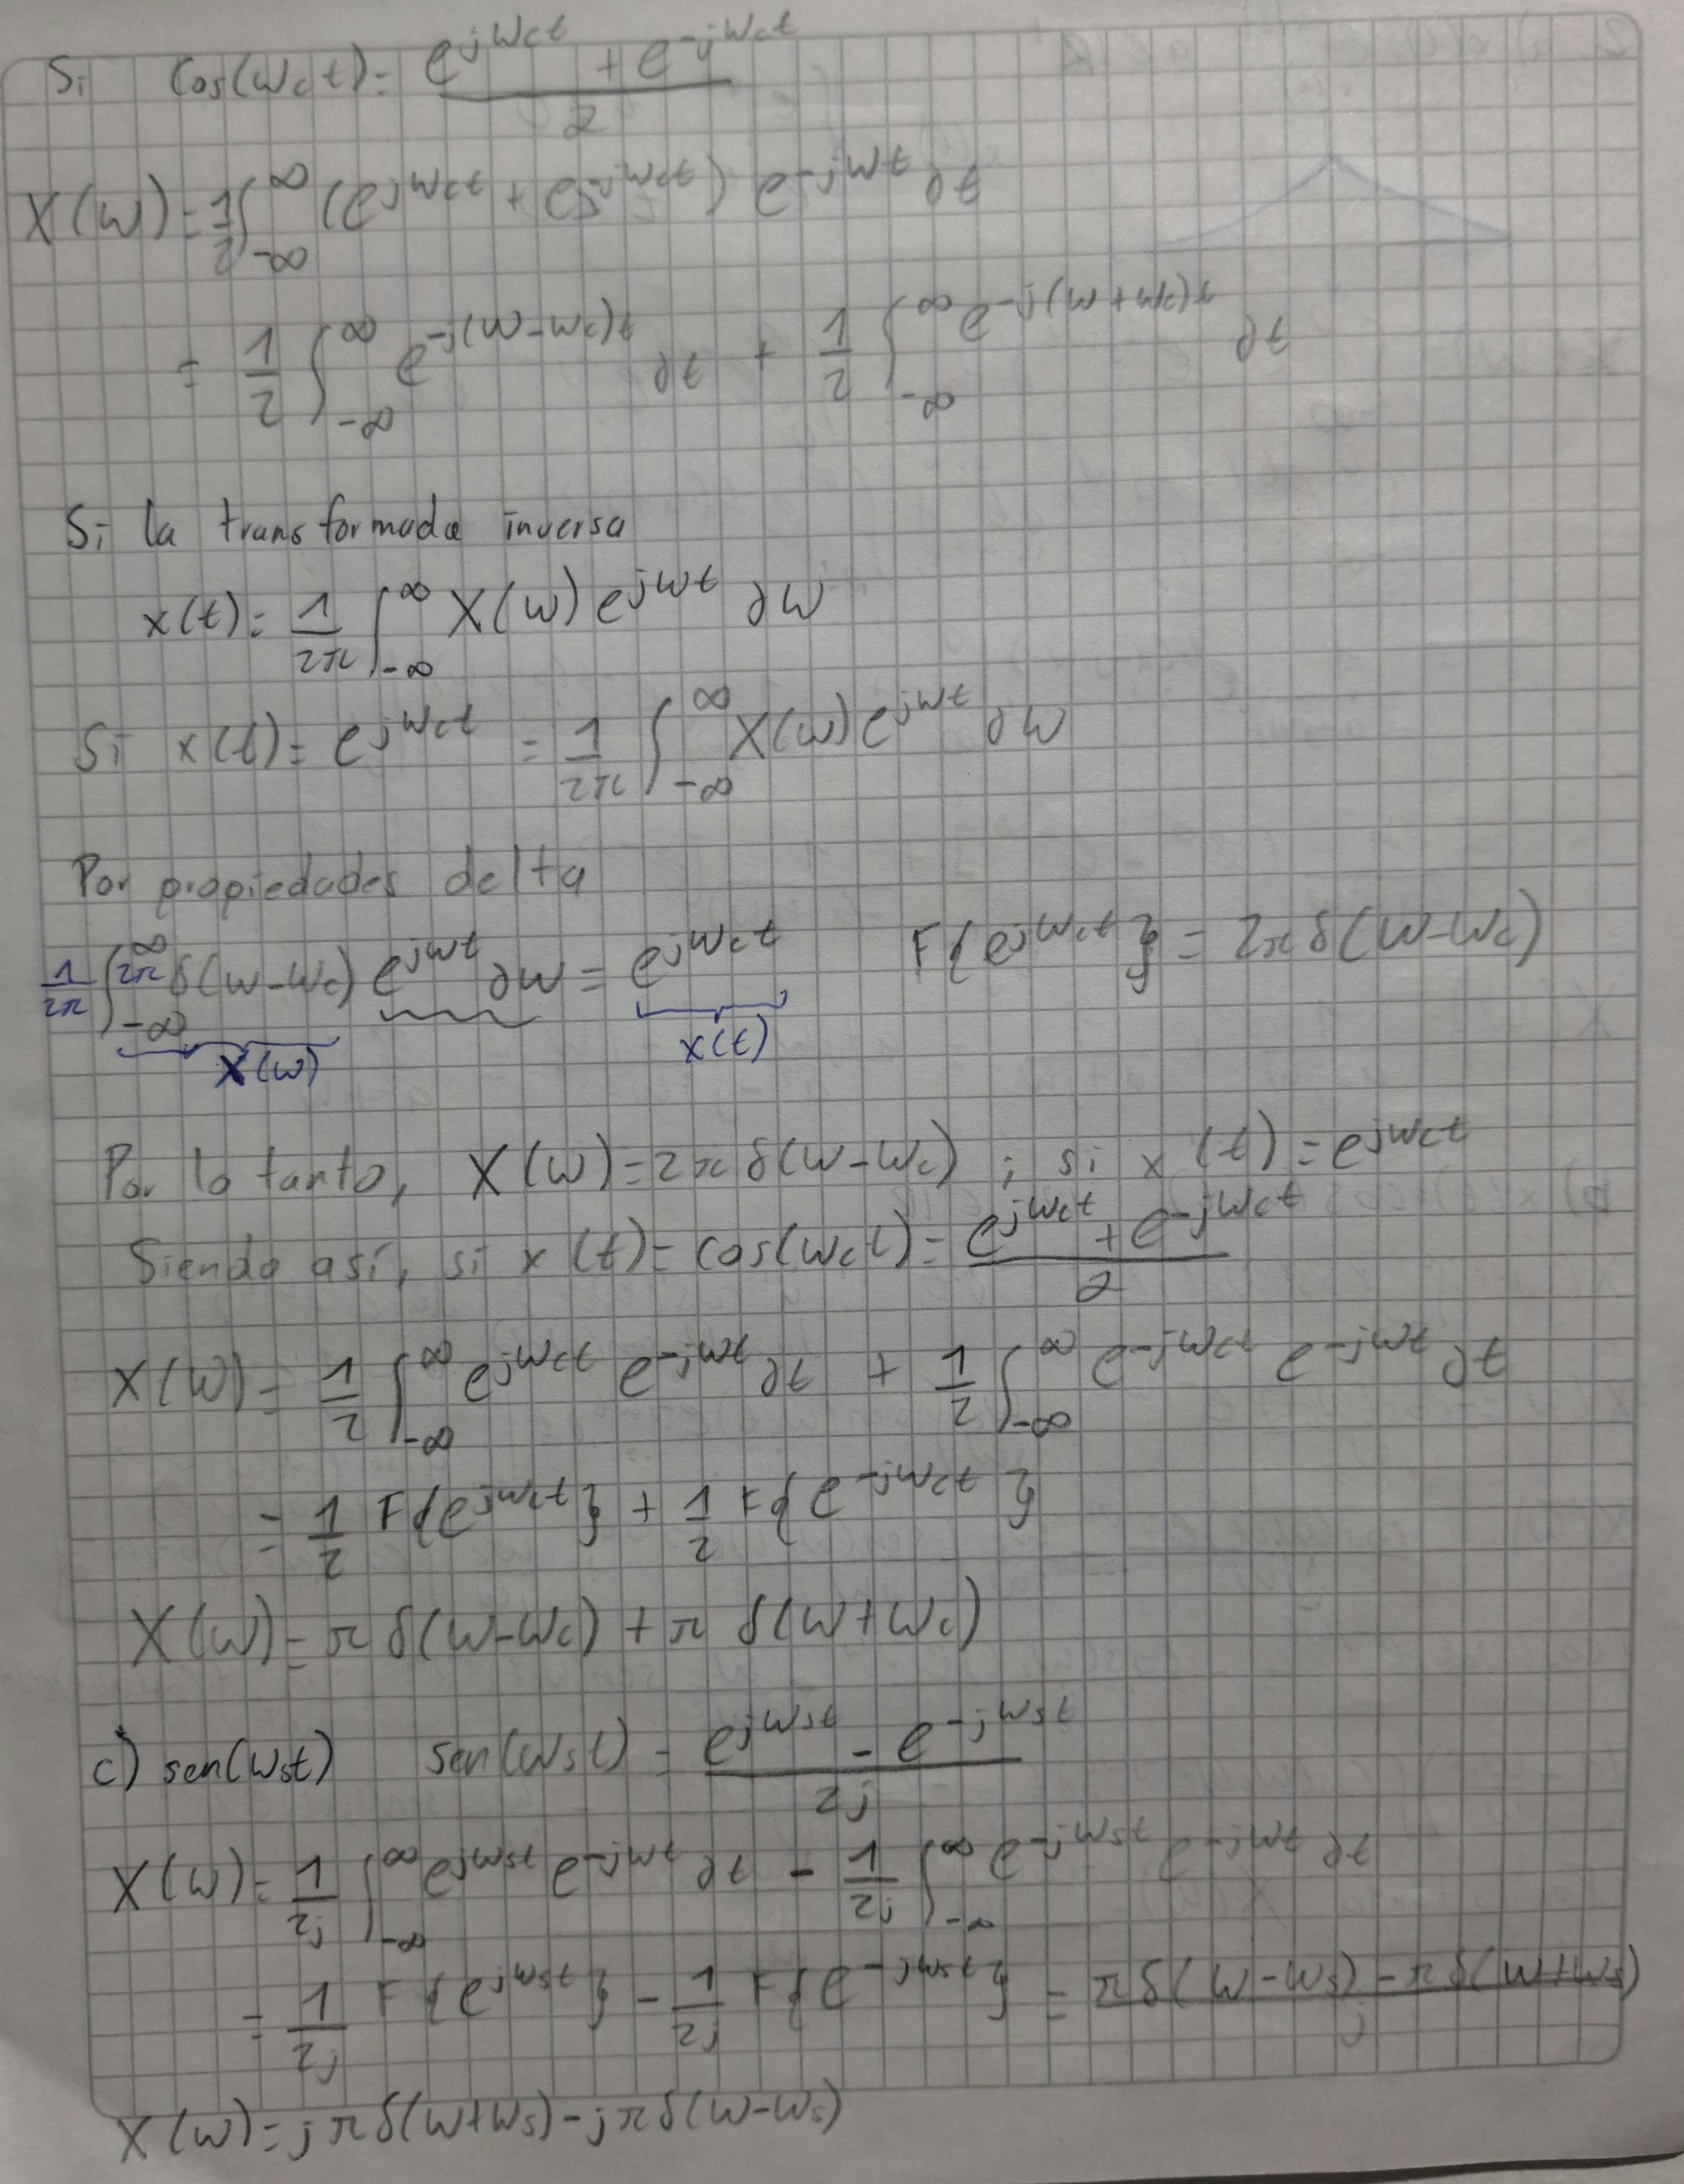

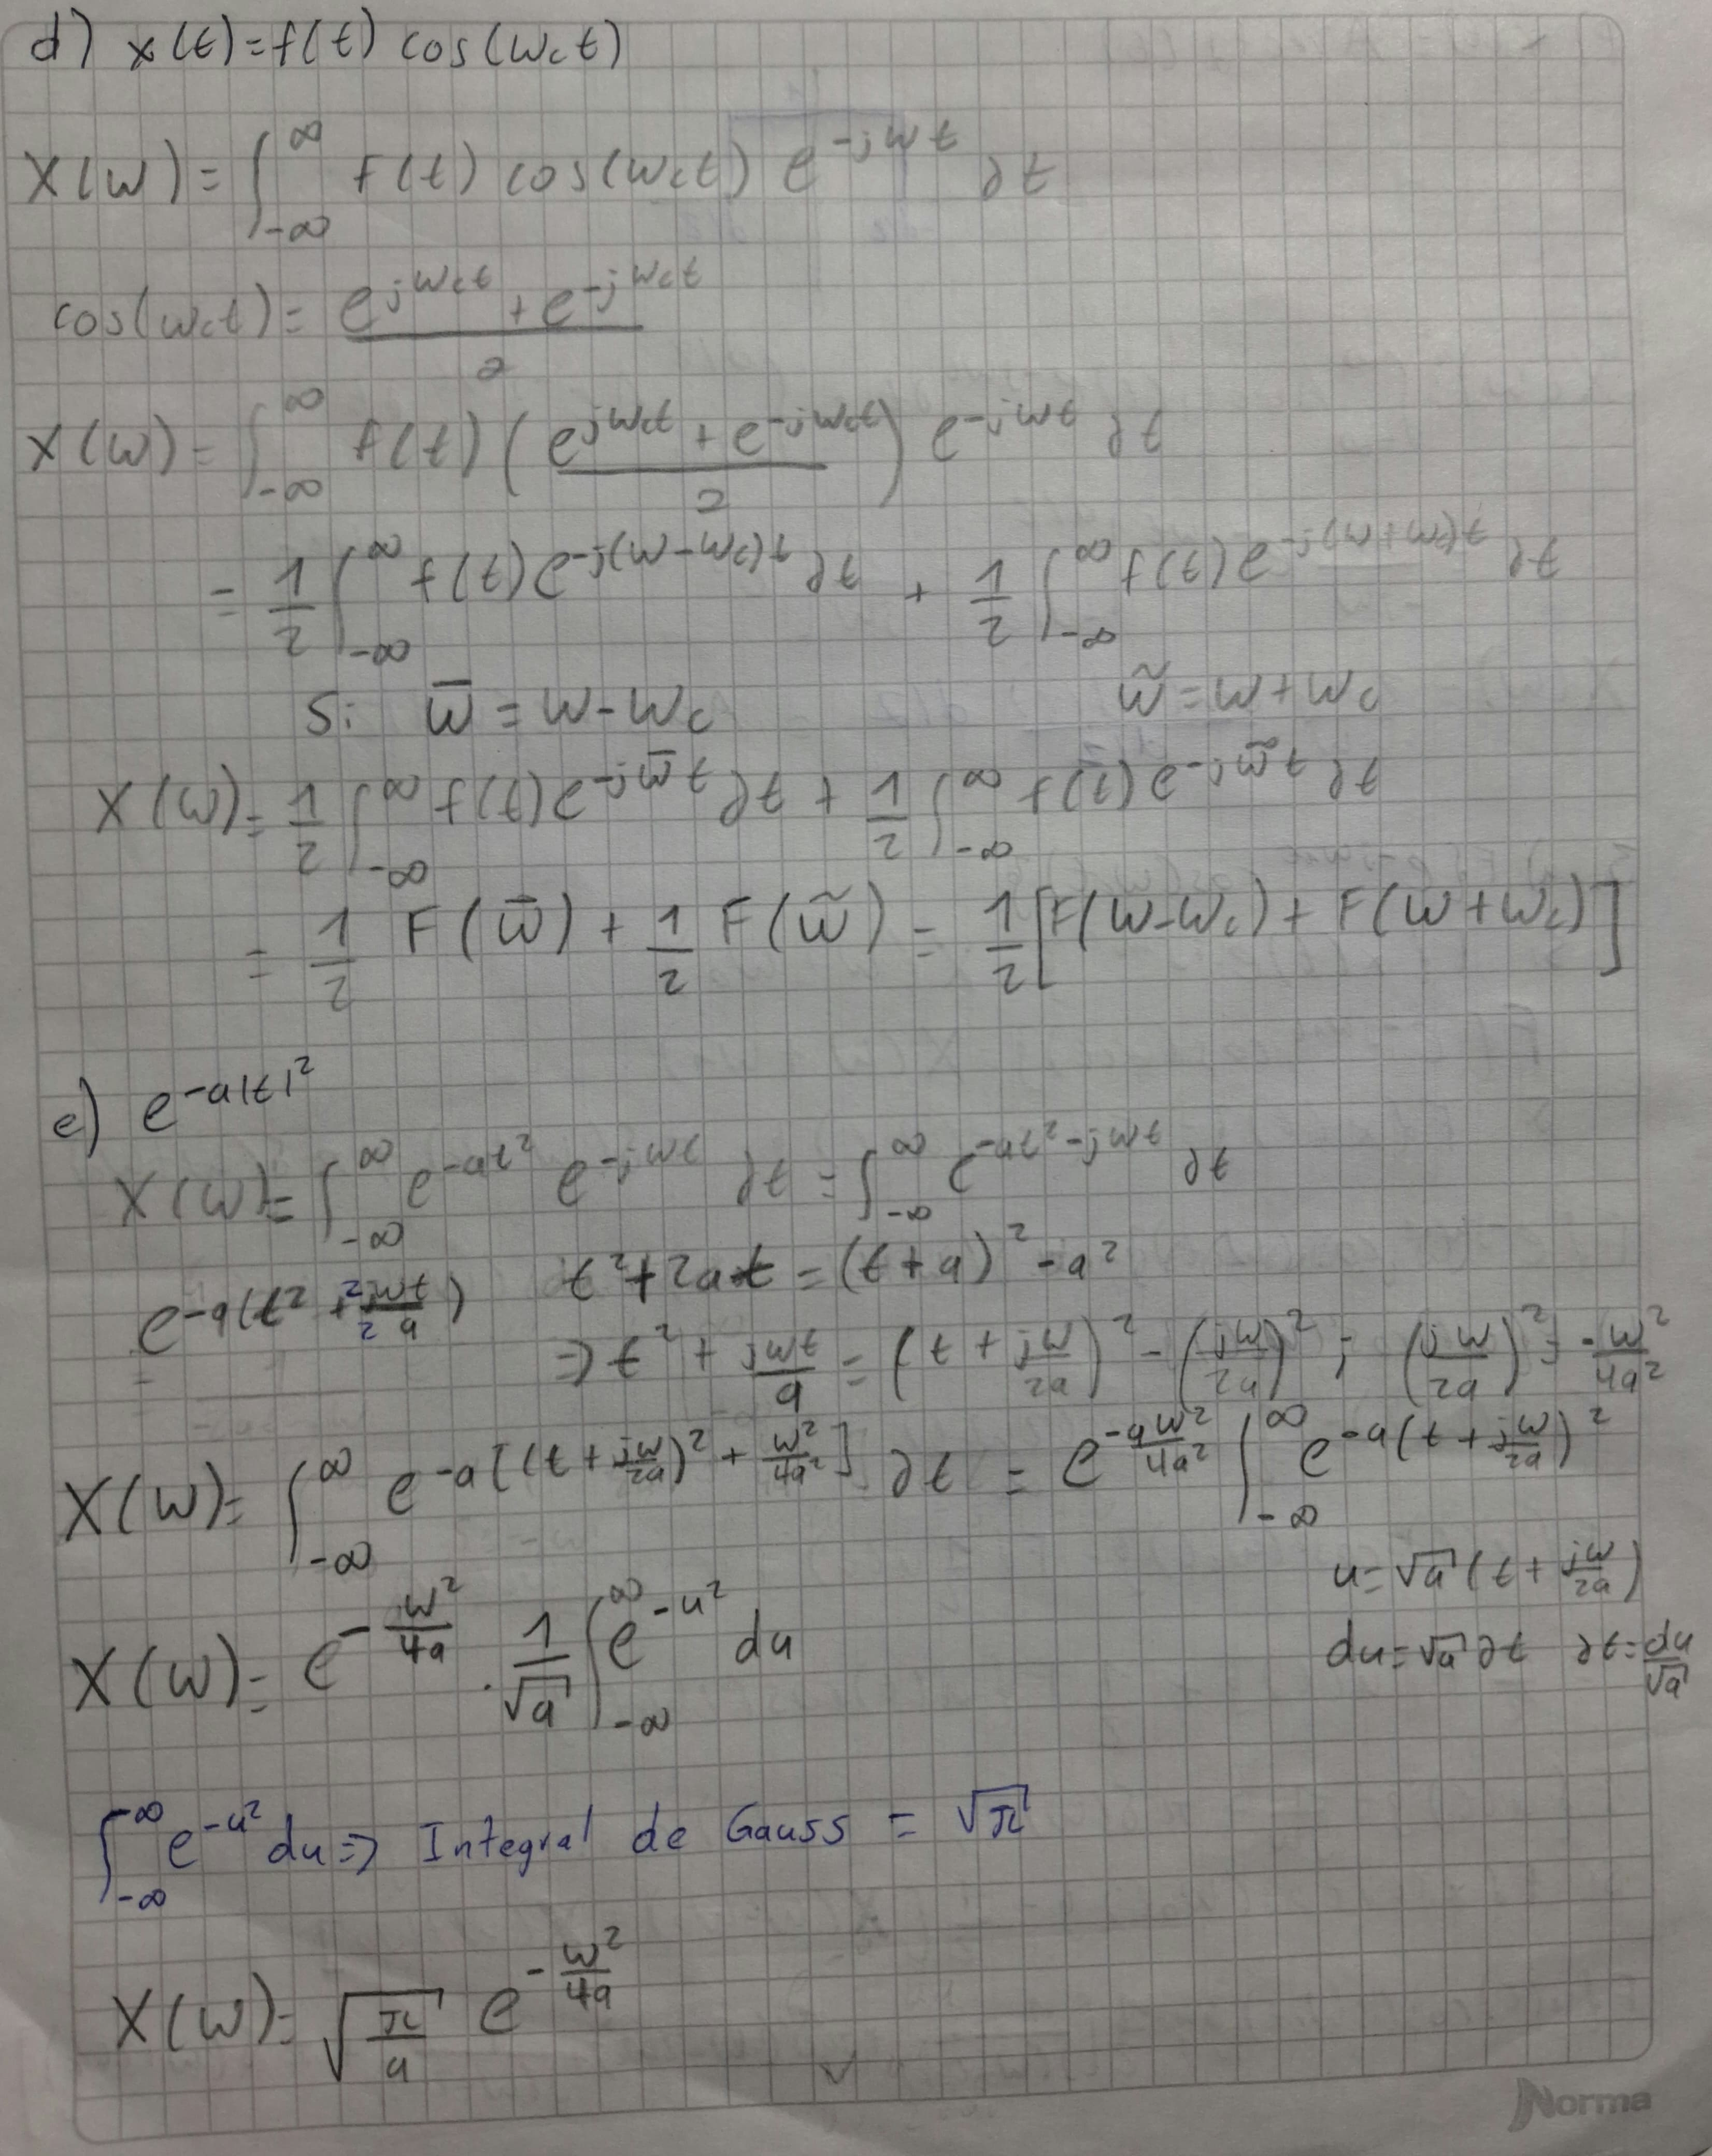

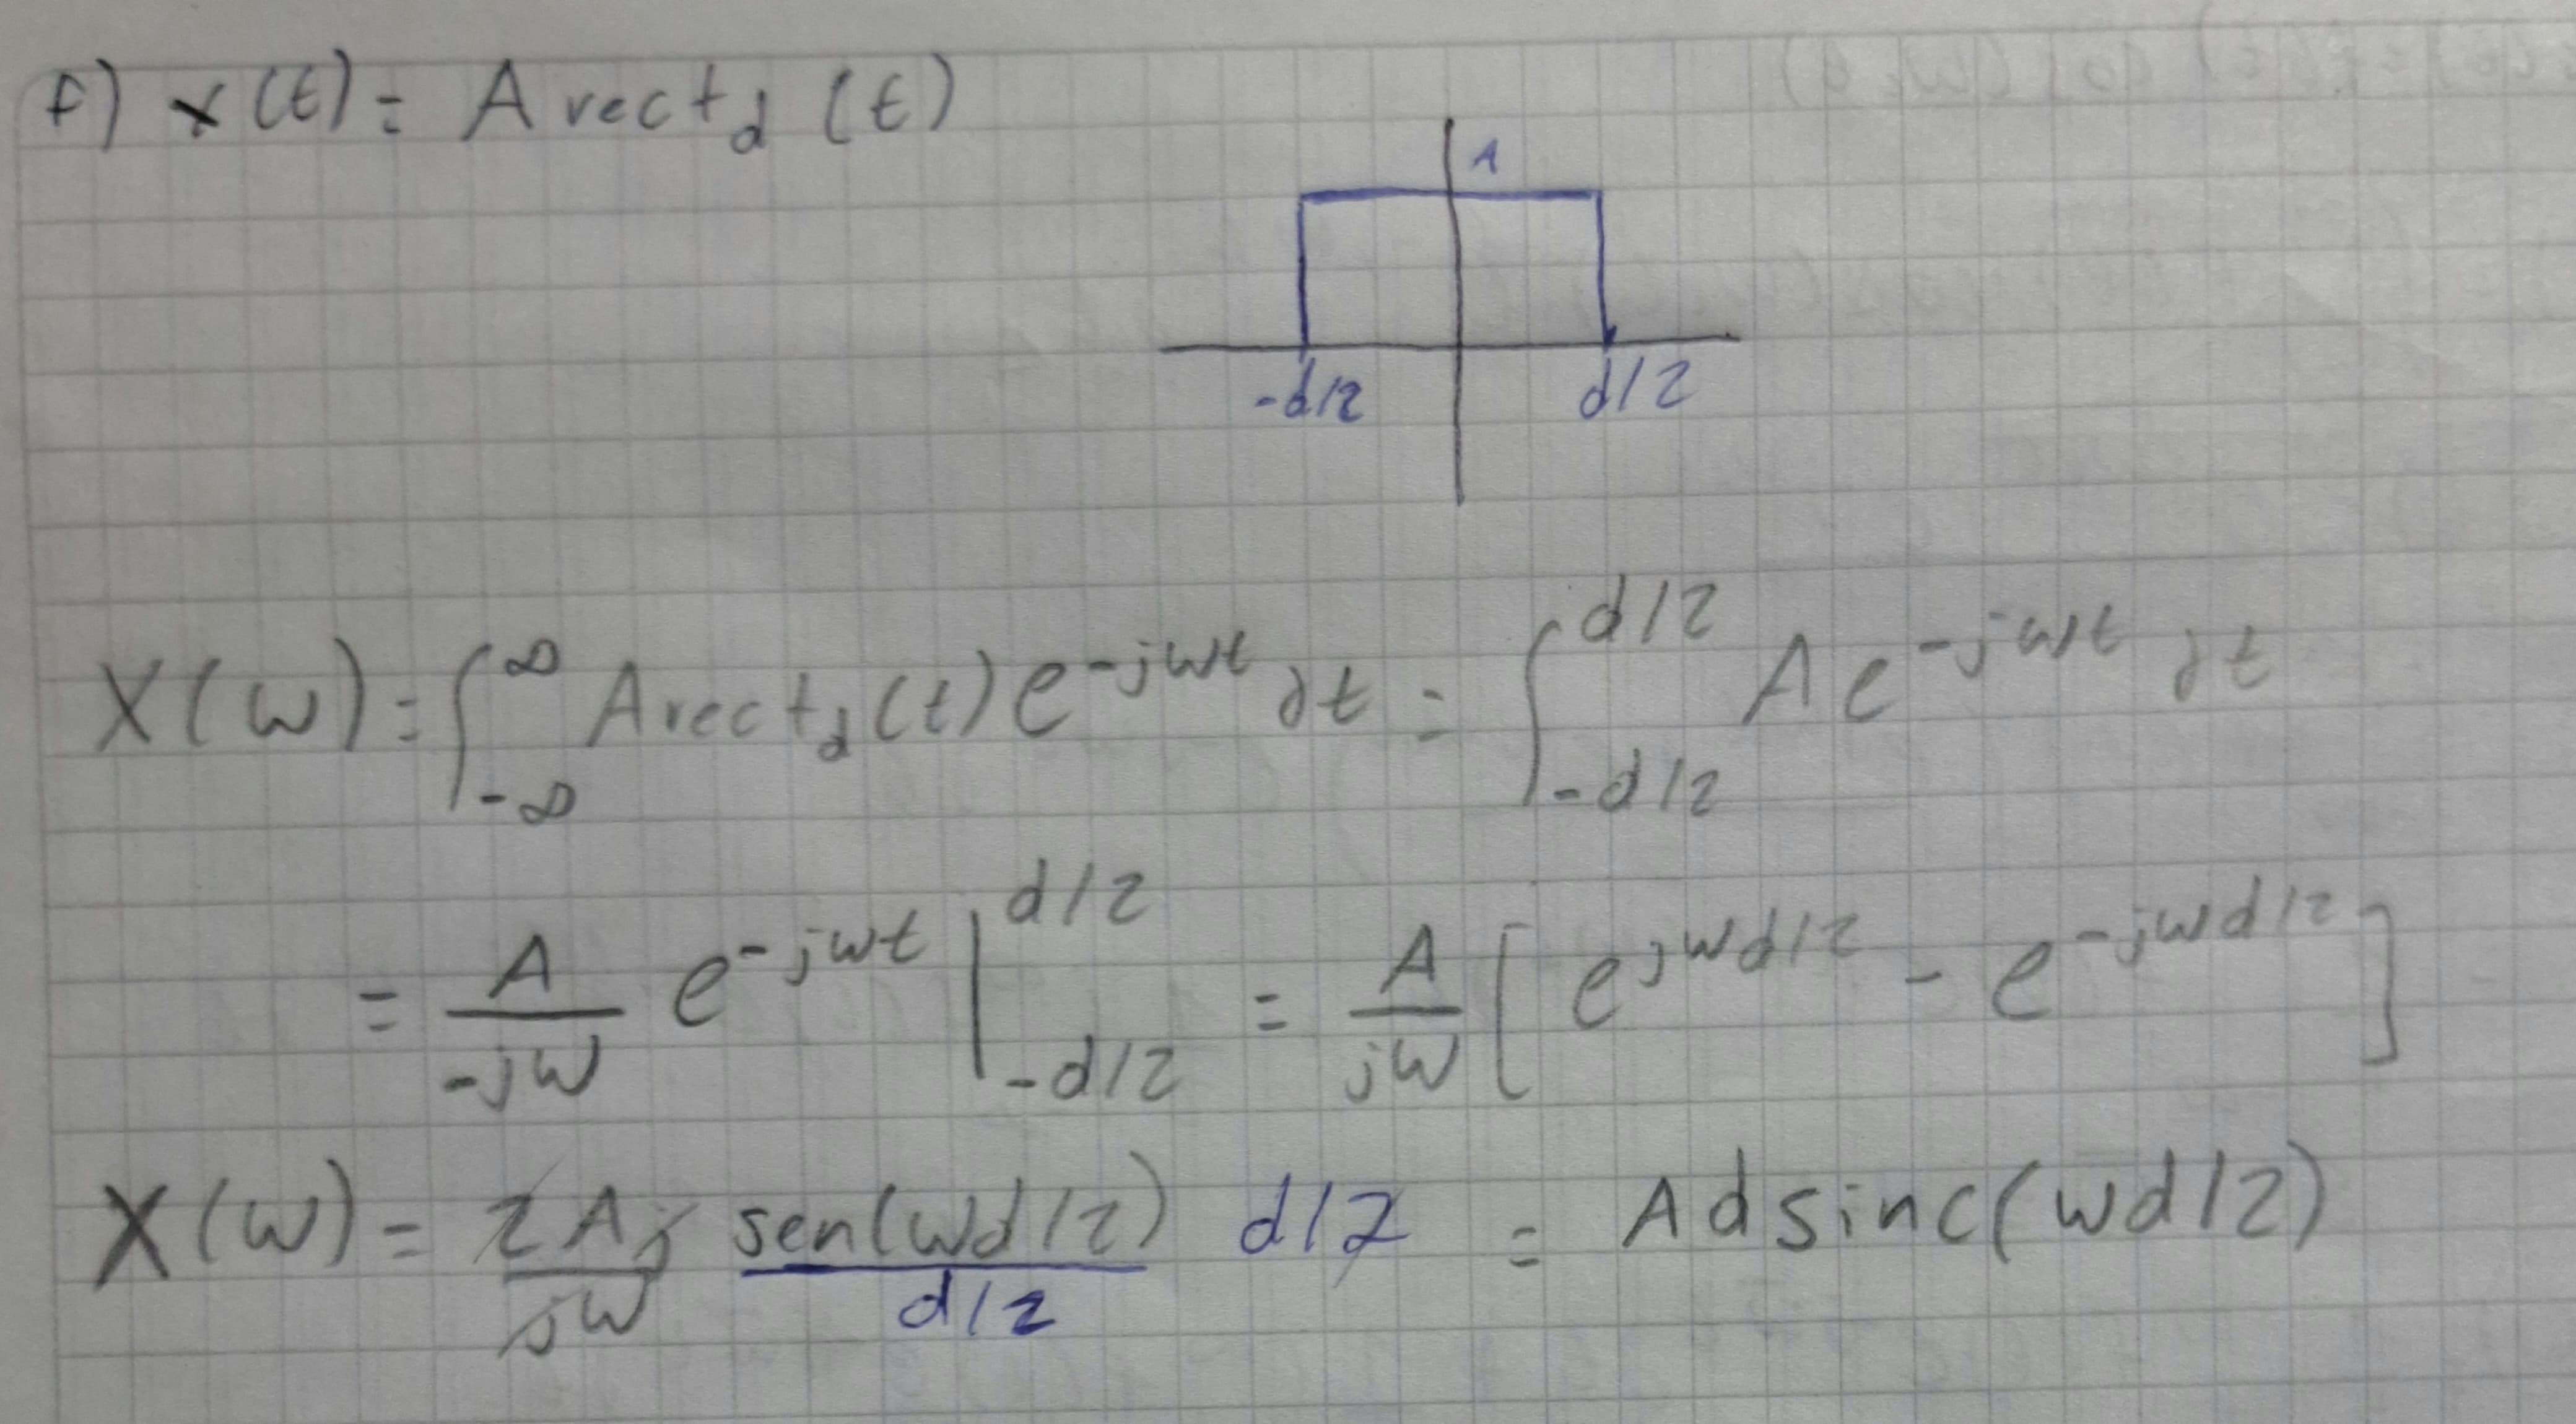

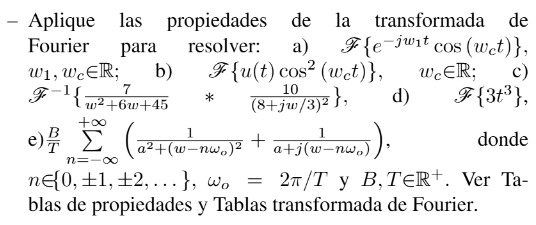

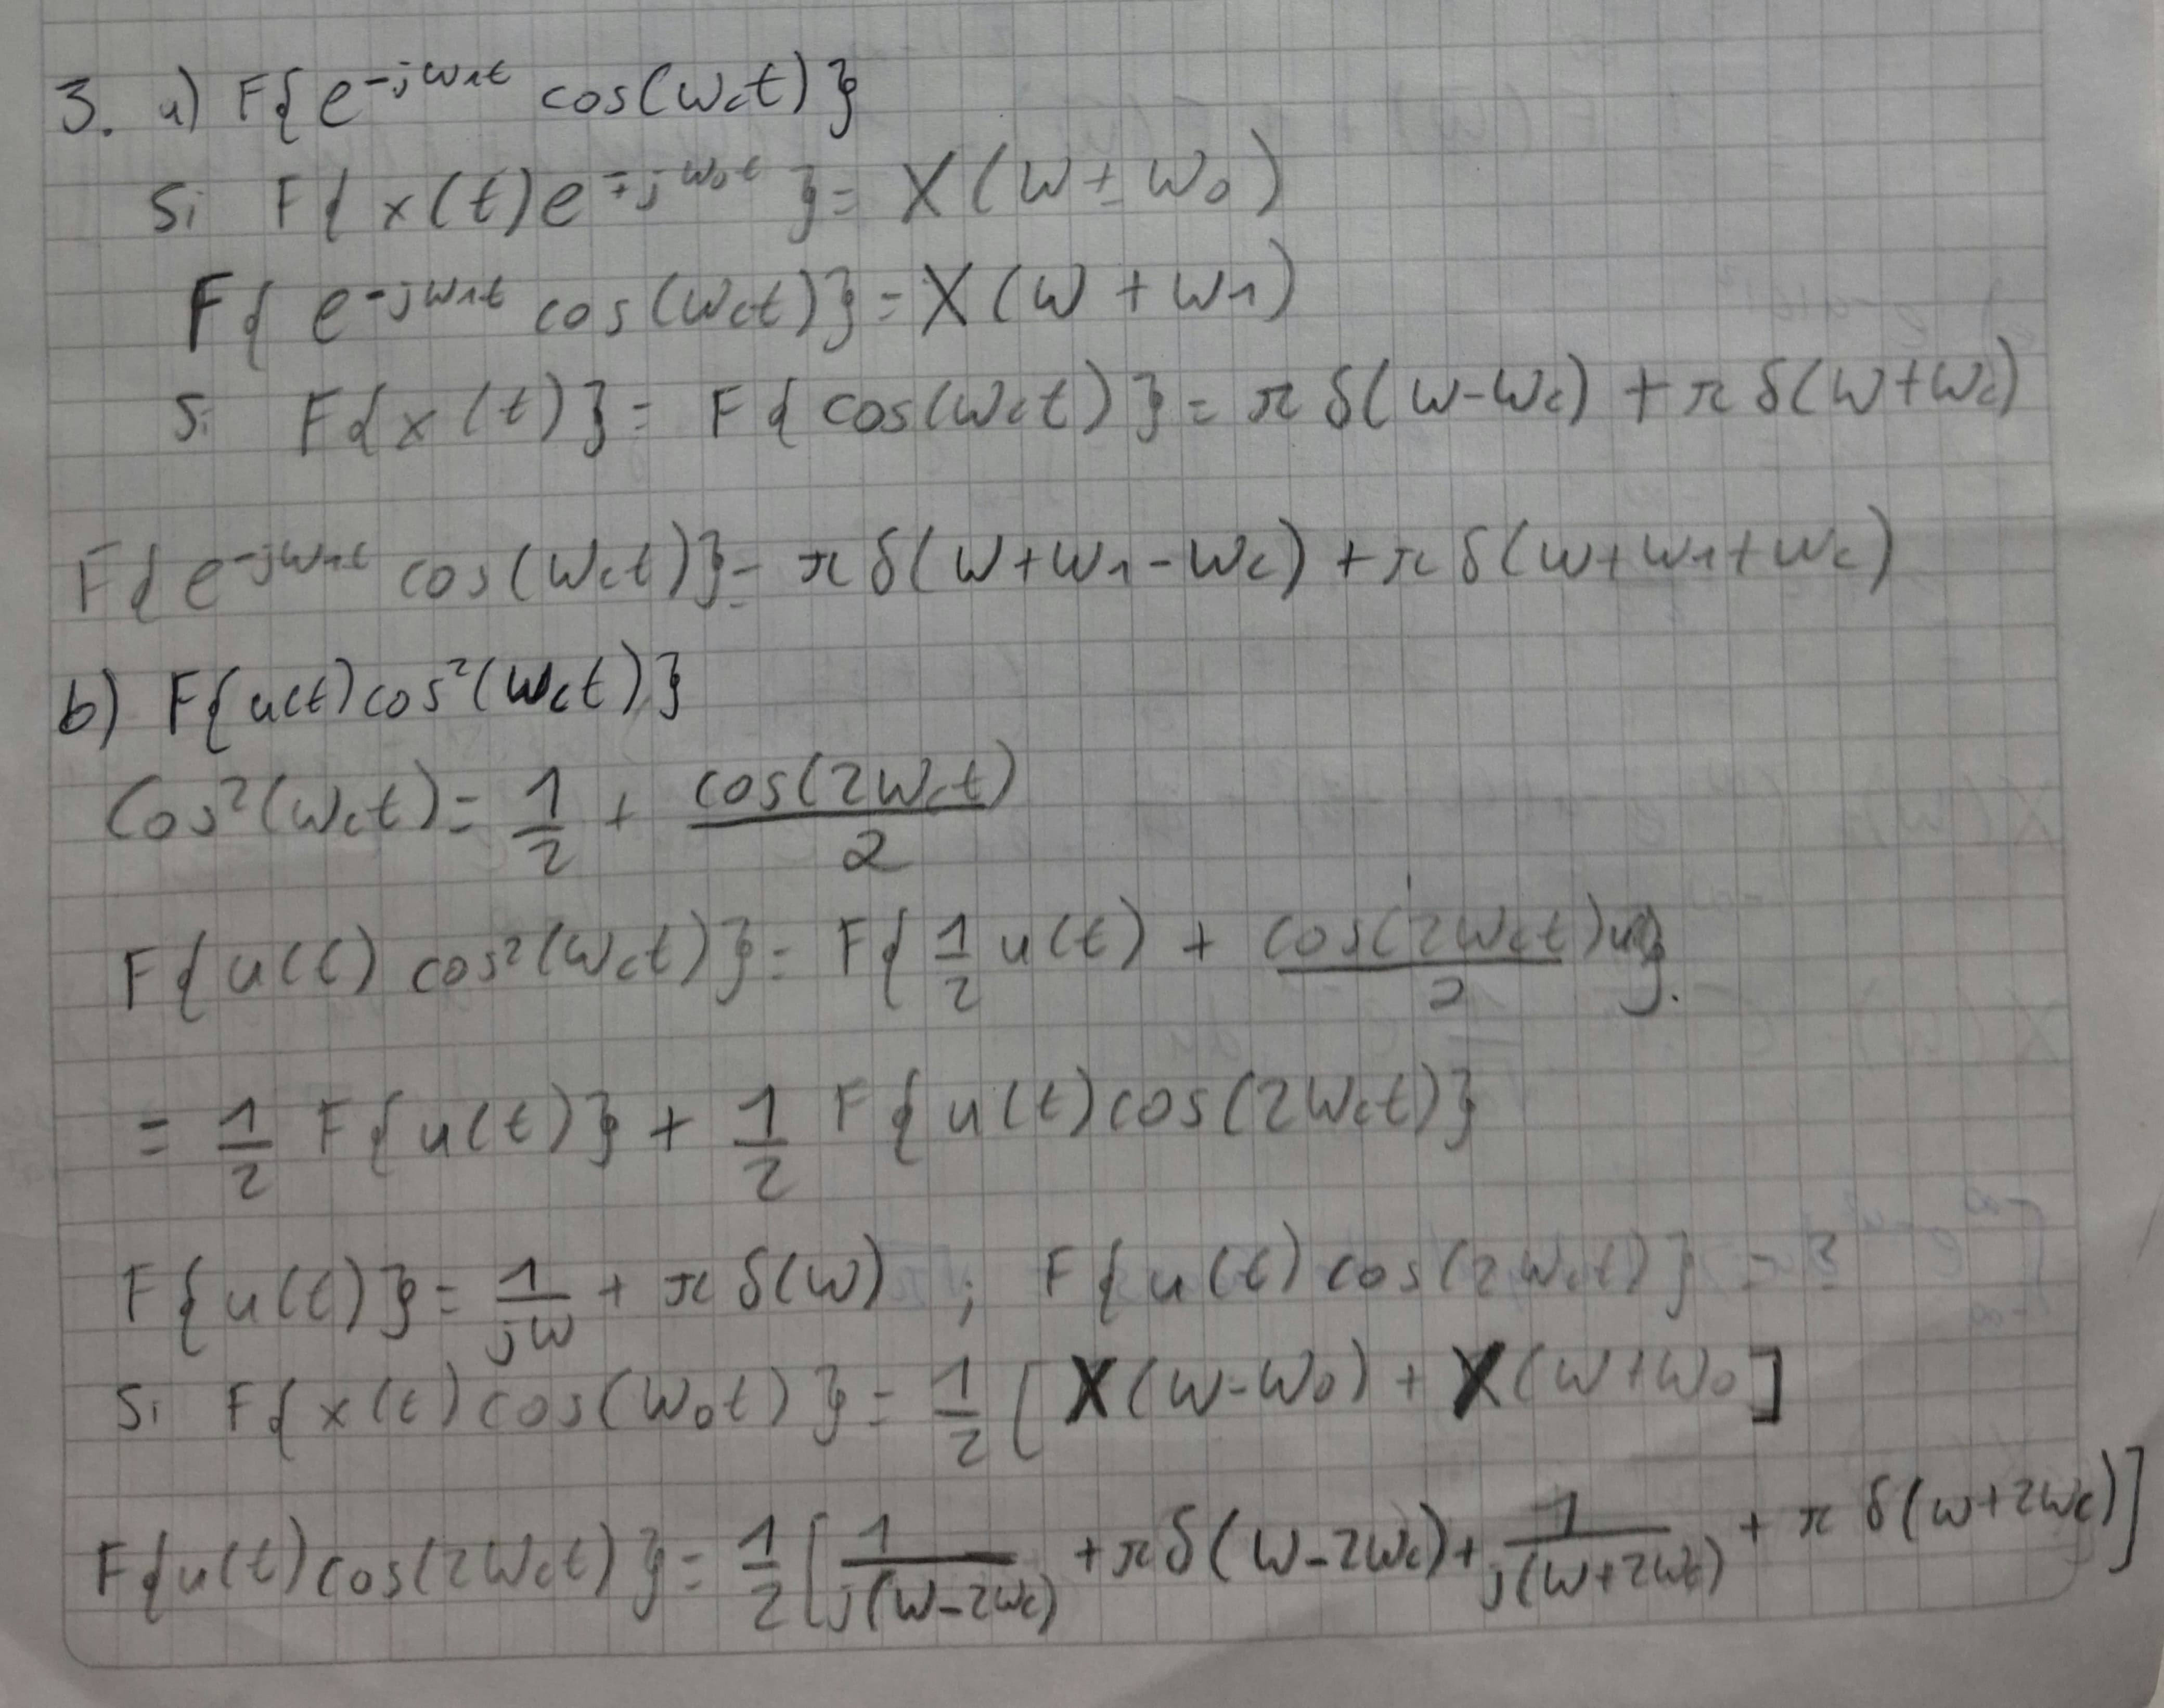

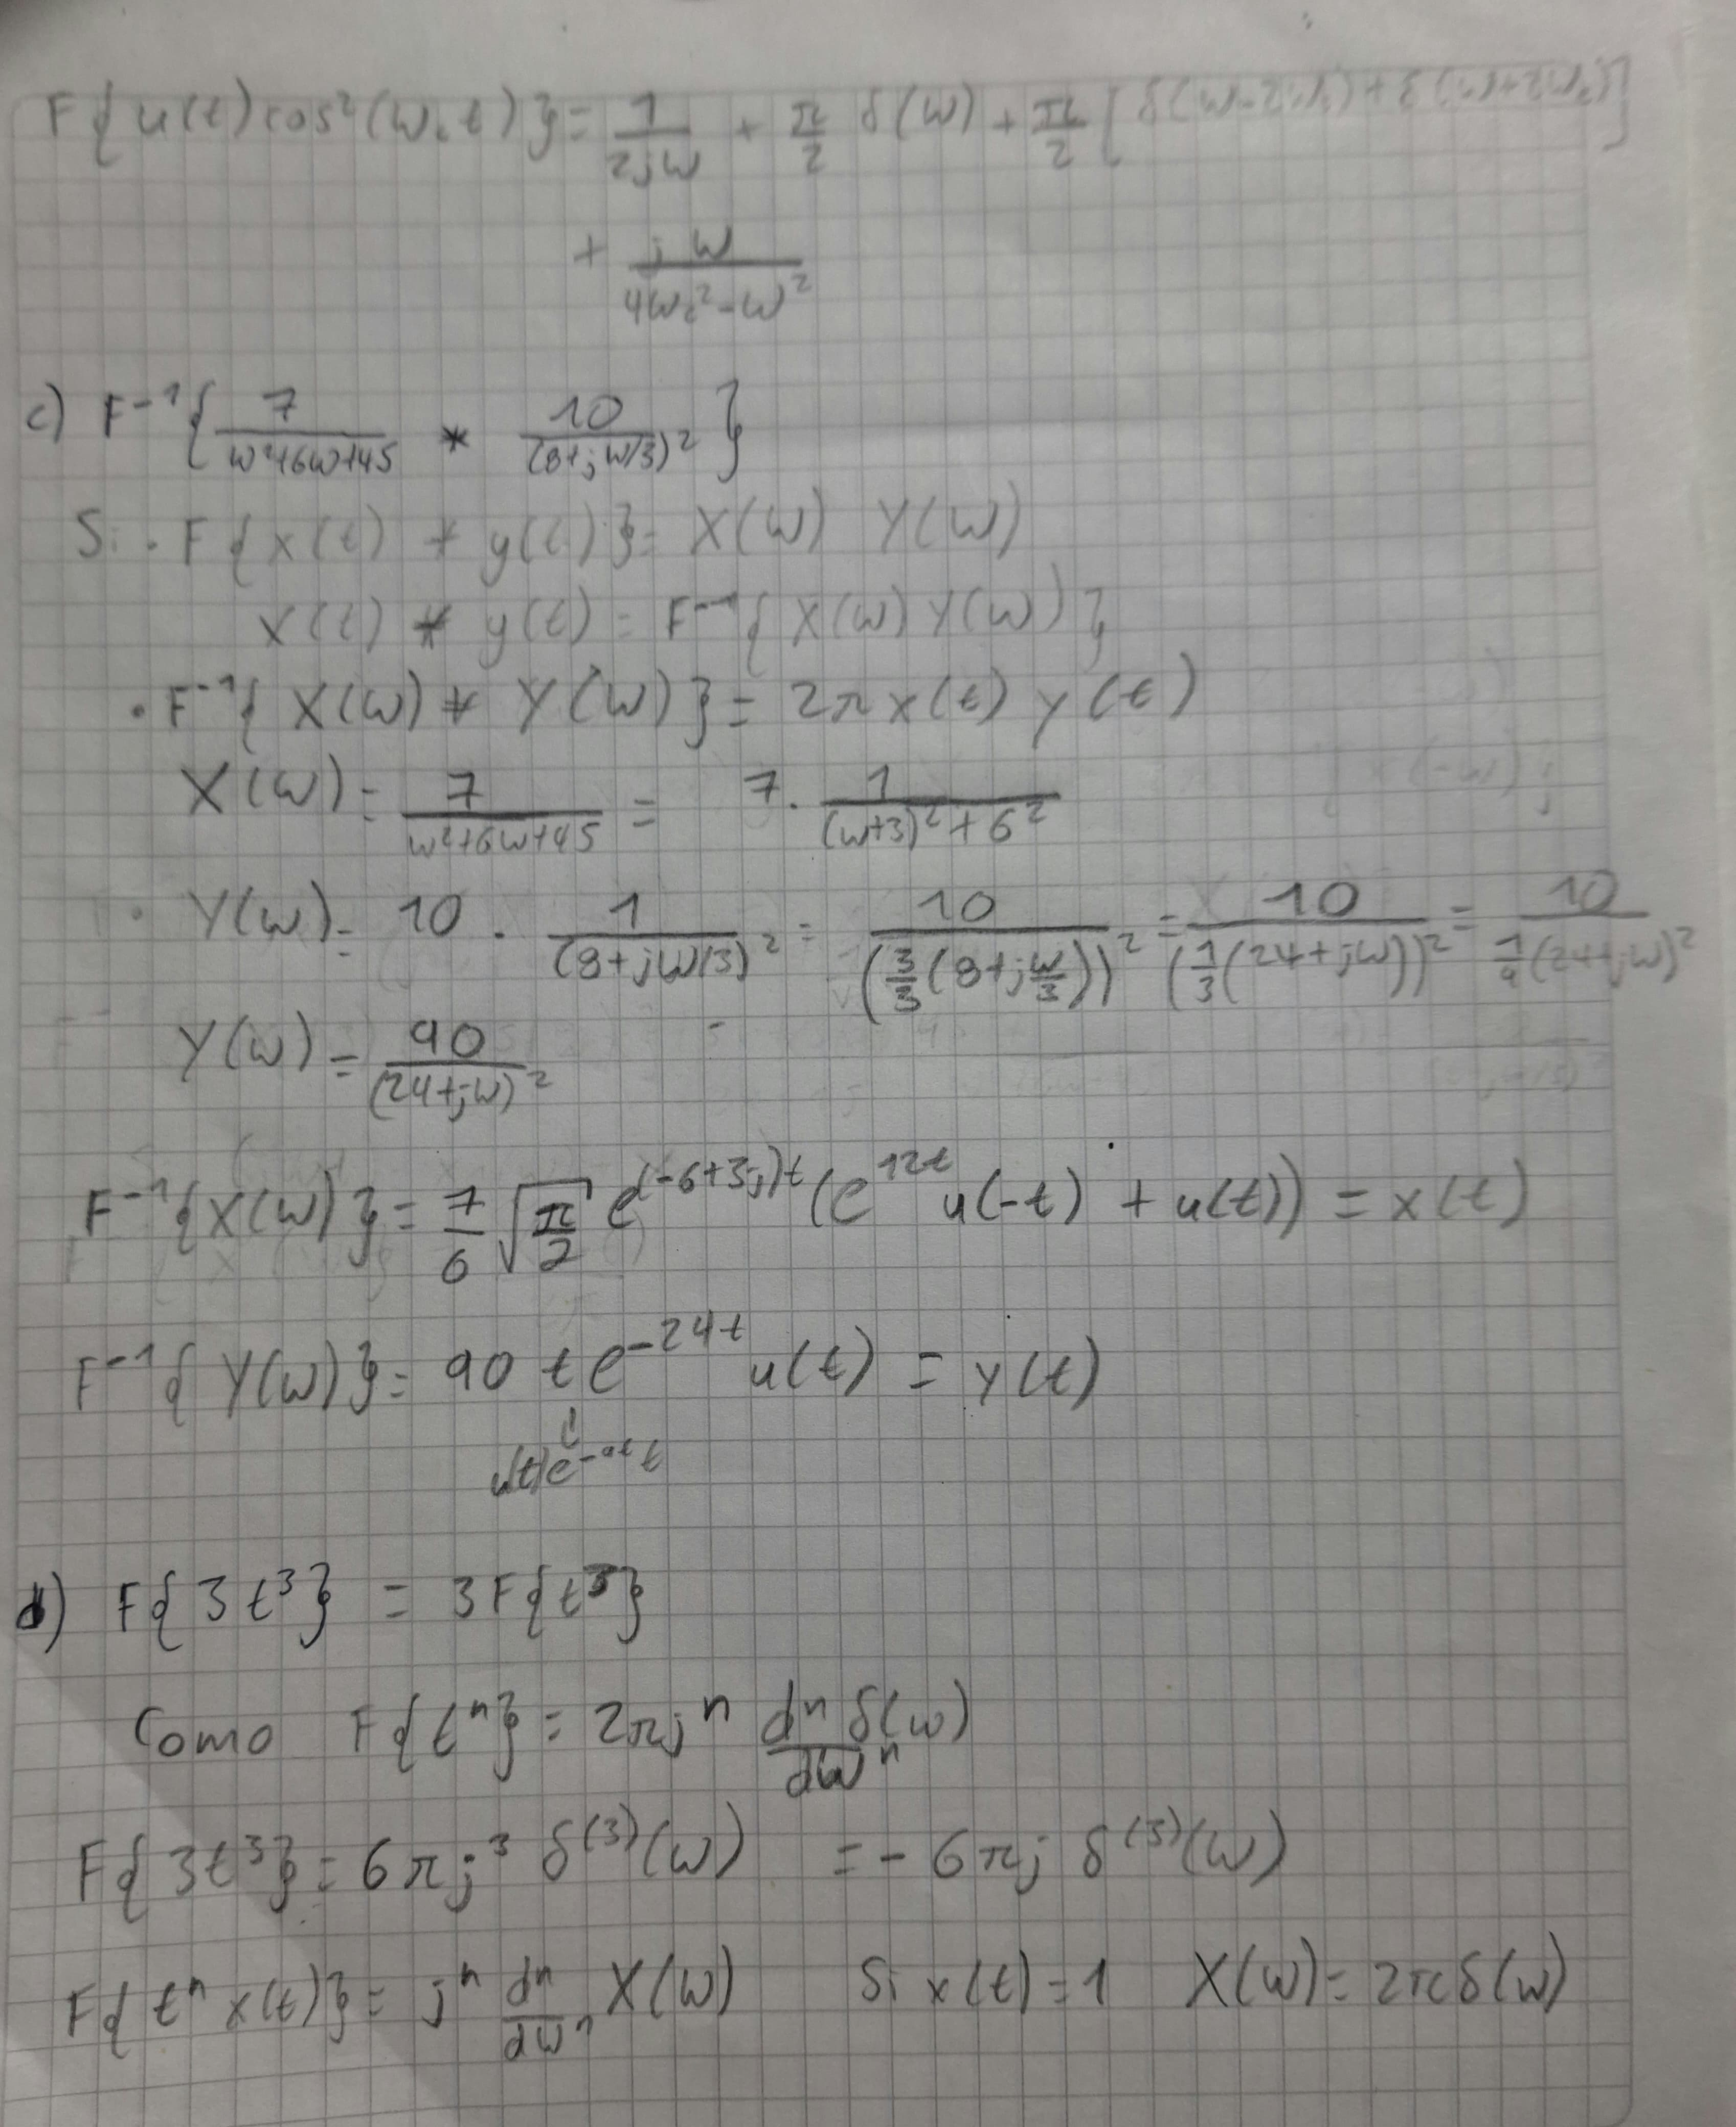

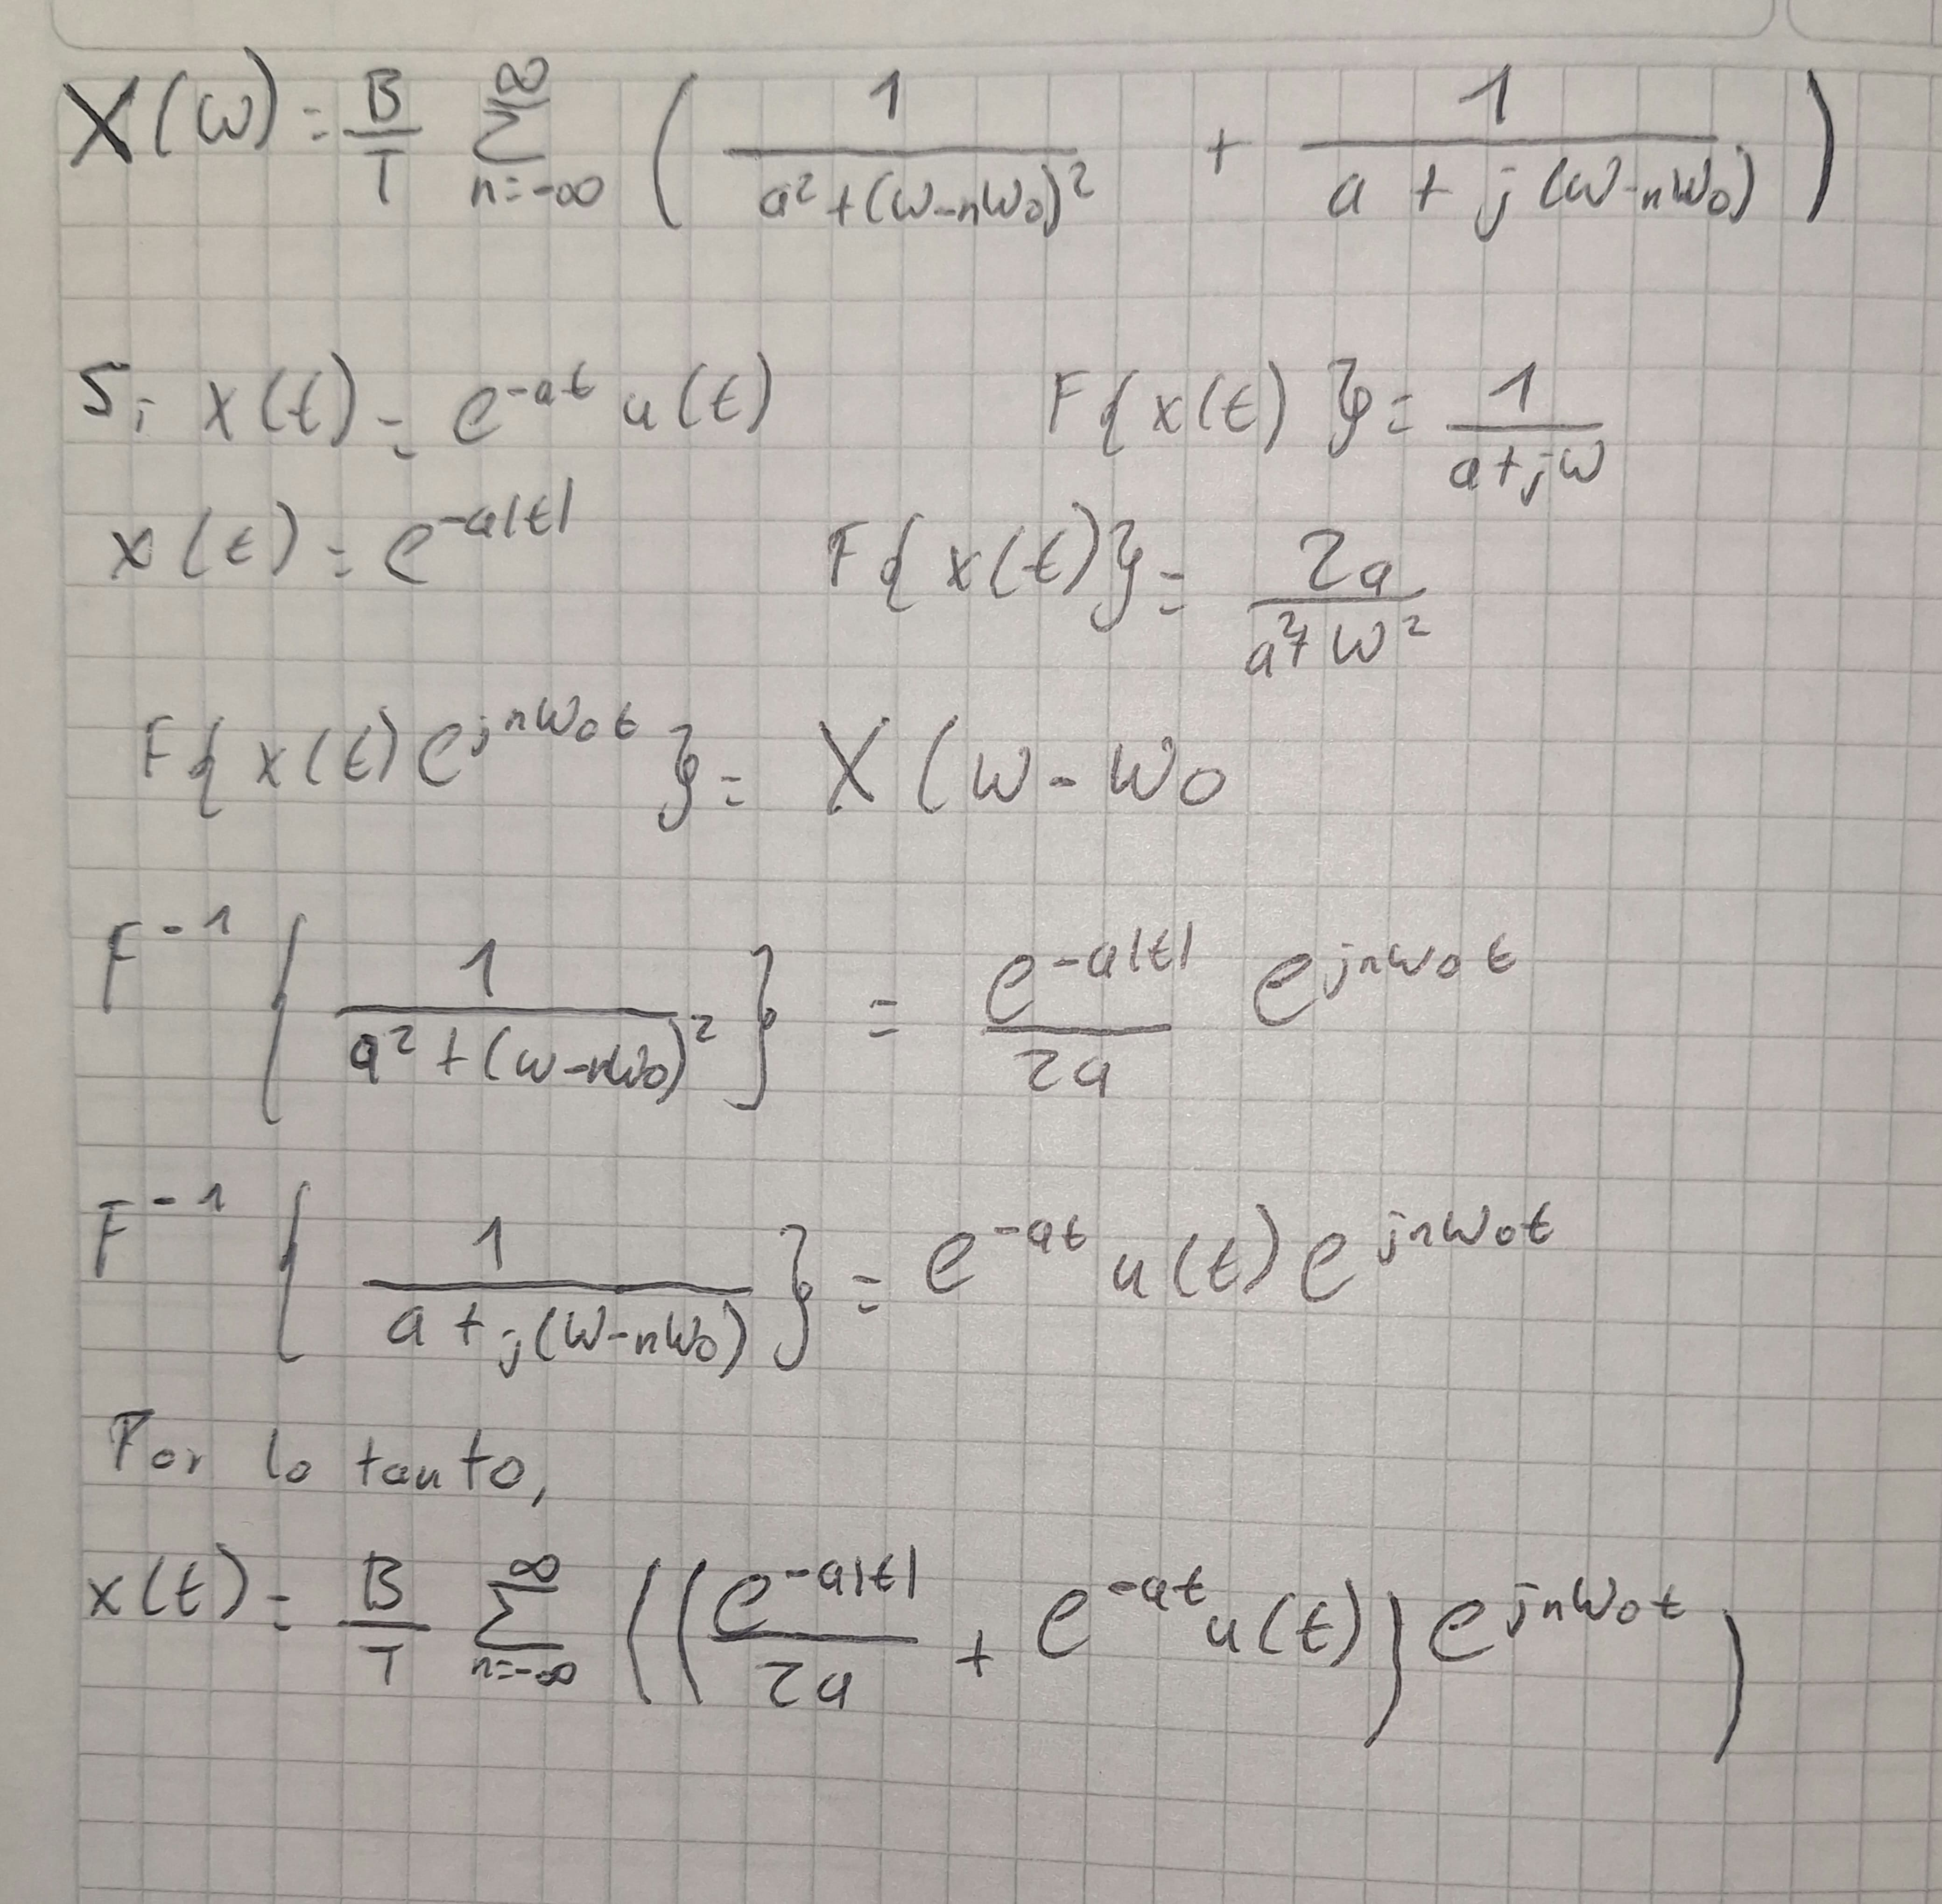

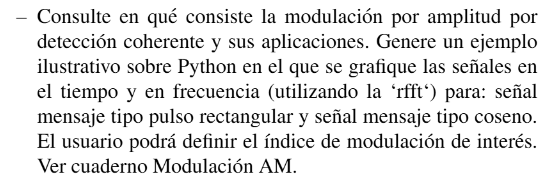

 ¿Qué es la modulación AM con detección coherente?

- La modulación por amplitud (AM) consiste en modificar la amplitud de una señal portadora de alta frecuencia en proporción a la señal de mensaje (información). La detección coherente es un método de demodulación que requiere un oscilador local en el receptor sincronizado en fase y frecuencia con la portadora original. Esto permite extraer la señal de mensaje de forma precisa.

Aplicaciones:

- Radiodifusión en AM (radio comercial)

- Comunicaciones aeronáuticas

- Transmisión de datos en frecuencias bajas

- Transmisiones analógicas simples en sistemas embebidos

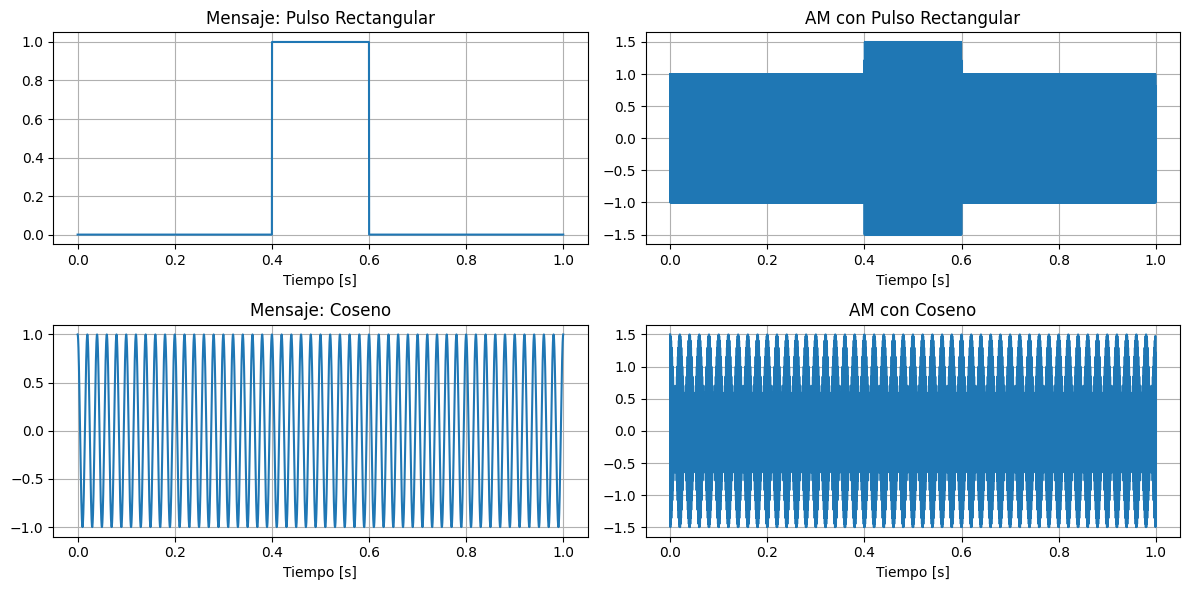

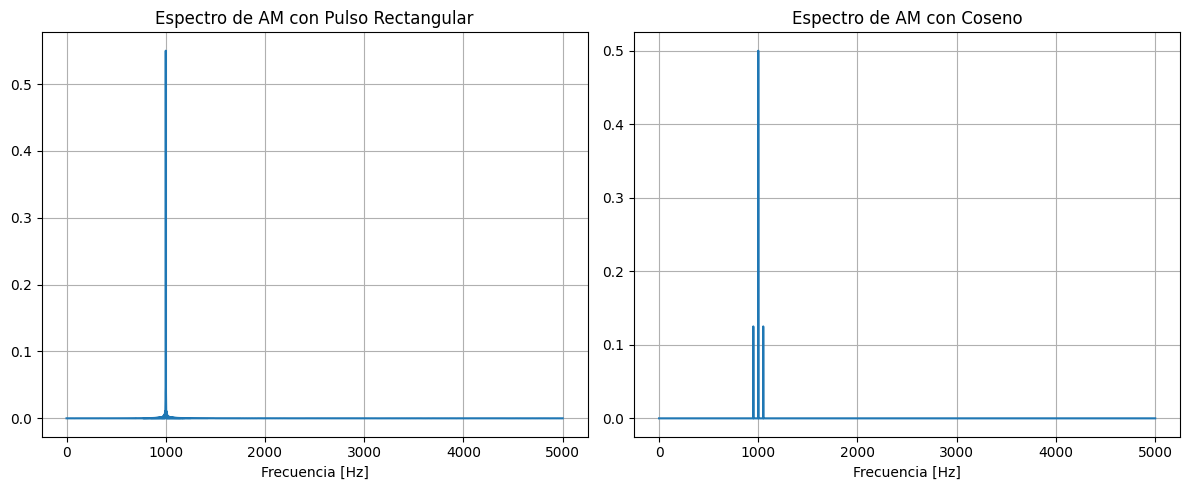

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

# Parámetros
fs = 10000  # Frecuencia de muestreo (Hz)
T = 1       # Duración (s)
t = np.linspace(0, T, int(fs*T), endpoint=False)

fc = 1000  # Frecuencia de la portadora (Hz)
Ac = 1     # Amplitud de la portadora
m = 0.5    # Índice de modulación (puede modificarse)

# Señales mensaje
# 1. Pulso rectangular (duración 0.2s en el centro de la señal)
mensaje_pulso = np.where((t > 0.4) & (t < 0.6), 1, 0)

# 2. Coseno (frecuencia baja)
fm = 50  # Frecuencia de mensaje (Hz)
mensaje_coseno = np.cos(2 * np.pi * fm * t)

# Señales moduladas AM
am_pulso = (1 + m * mensaje_pulso) * Ac * np.cos(2 * np.pi * fc * t)
am_coseno = (1 + m * mensaje_coseno) * Ac * np.cos(2 * np.pi * fc * t)

# Graficar señales en el tiempo
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(t, mensaje_pulso)
plt.title('Mensaje: Pulso Rectangular')
plt.xlabel('Tiempo [s]')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(t, am_pulso)
plt.title('AM con Pulso Rectangular')
plt.xlabel('Tiempo [s]')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(t, mensaje_coseno)
plt.title('Mensaje: Coseno')
plt.xlabel('Tiempo [s]')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(t, am_coseno)
plt.title('AM con Coseno')
plt.xlabel('Tiempo [s]')
plt.grid(True)

plt.tight_layout()
plt.show()

# Análisis en frecuencia
def plot_fft(signal, title):
    N = len(signal)
    yf = np.abs(rfft(signal)) / N
    xf = rfftfreq(N, 1/fs)
    plt.plot(xf, yf)
    plt.title(f'Espectro de {title}')
    plt.xlabel('Frecuencia [Hz]')
    plt.grid(True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_fft(am_pulso, 'AM con Pulso Rectangular')
plt.subplot(1, 2, 2)
plot_fft(am_coseno, 'AM con Coseno')
plt.tight_layout()
plt.show()


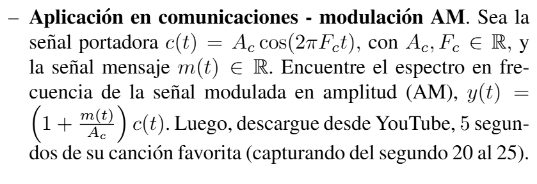

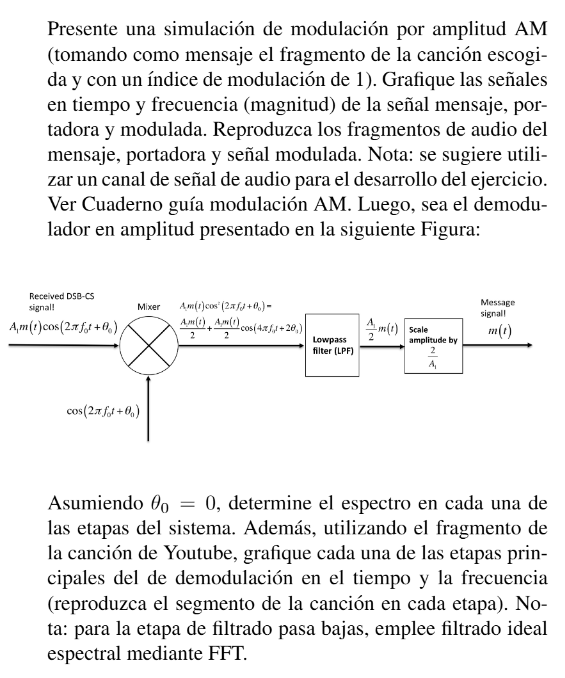

Señal mensaje tipo coseno

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#Frecuencia portadora y muestreo

Fc = 100 #frecuencia de portadora

Fm = 10 #frecuencia del mensaje
Am = 1 #amplitud del mensaje


ti = 0
tf = 5/Fm #cantidad de periodos a graficar de la

Fs = 5*Fc #frecuencia muestreo

t = np.arange(ti,tf,1/Fs) #vector del tiempo
m = Am*np.cos(2*np.pi*Fm*t) #mensaje

Im = float(input("Ingrese Im: ")) # Im = peak(m(t))/Ac ->  Ac = peak(m(t))/Im

Ac = max(abs(m))/Im #amplitud de la portadora según índice de modulación
c = Ac*np.sin(2*np.pi*Fc*t) #portadora
print(Ac)

Ingrese Im: 5
0.2


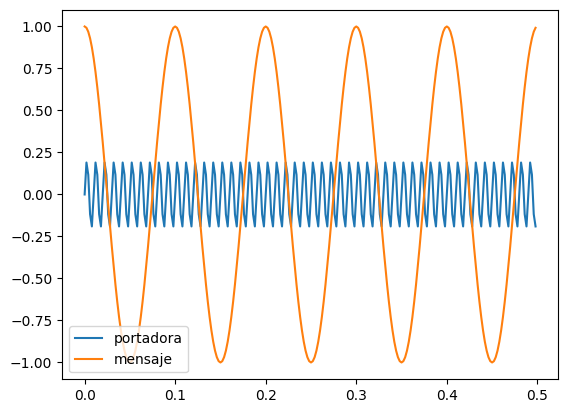

In [3]:
plt.plot(t,c,label='portadora')
plt.plot(t,m,label='mensaje')
plt.legend()
plt.show()

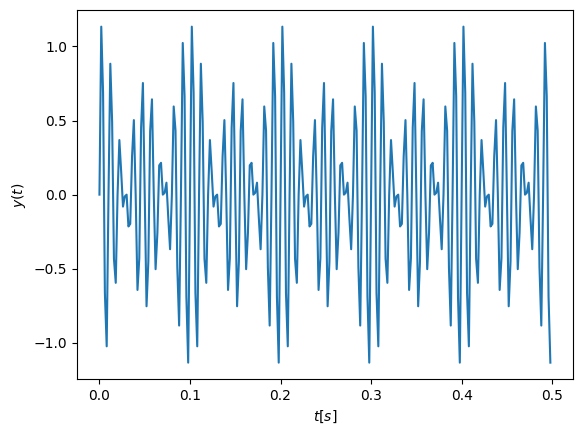

In [4]:
y = (1+m/Ac)*c #señal modulada en AM
plt.plot(t,y)
plt.xlabel('$t[s]$')
plt.ylabel('$y(t)$')
plt.show()

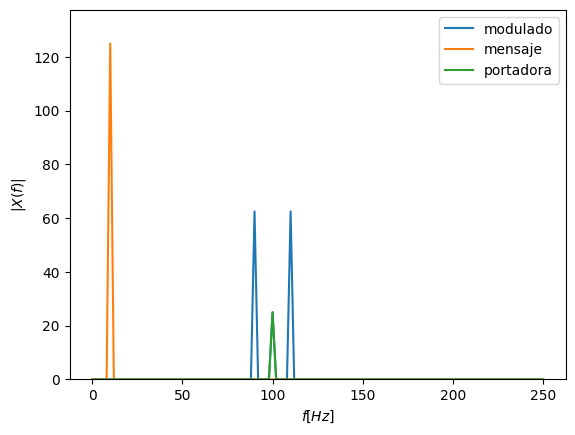

In [5]:
Xfc = np.fft.rfft(c)
Xfm = np.fft.rfft(m)
Xfy = np.fft.rfft(y)

vfre = np.fft.rfftfreq(len(c),1/Fs)

plt.plot(vfre,abs(Xfy),label='modulado')
plt.plot(vfre,abs(Xfm),label='mensaje')
plt.plot(vfre,abs(Xfc),label='portadora')
plt.legend()
plt.xlabel('$f [Hz]$')
plt.ylabel('$|X(f)|$')
plt.ylim([min(abs(Xfm)), 1.1*max(abs(Xfm))])
plt.show()

Señal mensaje tipo pulso

In [7]:
import numpy as np
import matplotlib.pyplot as plt
#Frecuencia portadora y muestreo

Fc = 100 #frecuencia de portadora

Fm = 10 #frecuencia del mensaje
Am = 1 #amplitud del mensaje


ti = 0
tf = 5/Fm #cantidad de periodos a graficar de la

Fs = 5*Fc #frecuencia muestreo

t = np.arange(ti,tf,1/Fs) #vector del tiempo
m = np.zeros (len(t)) #mensaje
m[(t>=0.1)&(t<=0.4)] = Am

Im = float(input("Ingrese Im: ")) # Im = peak(m(t))/Ac ->  Ac = peak(m(t))/Im

Ac = max(abs(m))/Im #amplitud de la portadora según índice de modulación
c = Ac*np.sin(2*np.pi*Fc*t) #portadora
print(Ac)

Ingrese Im: 5
0.2


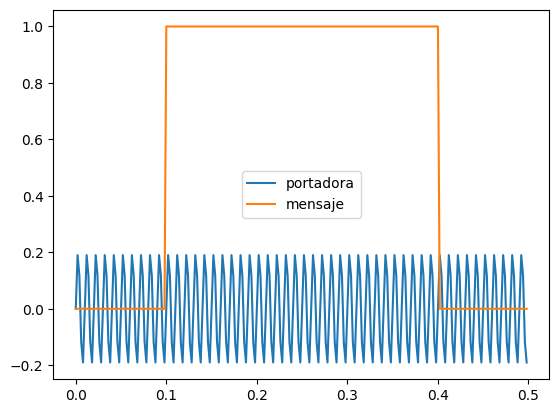

In [8]:
plt.plot(t,c,label='portadora')
plt.plot(t,m,label='mensaje')
plt.legend()
plt.show()

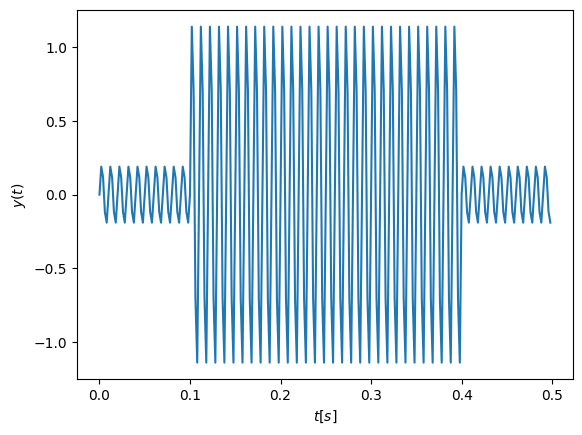

In [9]:
y = (1+m/Ac)*c #señal modulada en AM
plt.plot(t,y)
plt.xlabel('$t[s]$')
plt.ylabel('$y(t)$')
plt.show()

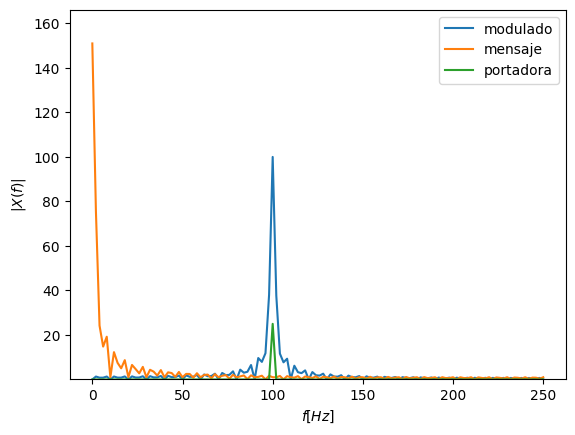

In [10]:
Xfc = np.fft.rfft(c)
Xfm = np.fft.rfft(m)
Xfy = np.fft.rfft(y)

vfre = np.fft.rfftfreq(len(c),1/Fs)

plt.plot(vfre,abs(Xfy),label='modulado')
plt.plot(vfre,abs(Xfm),label='mensaje')
plt.plot(vfre,abs(Xfc),label='portadora')
plt.legend()
plt.xlabel('$f [Hz]$')
plt.ylabel('$|X(f)|$')
plt.ylim([min(abs(Xfm)), 1.1*max(abs(Xfm))])
plt.show()

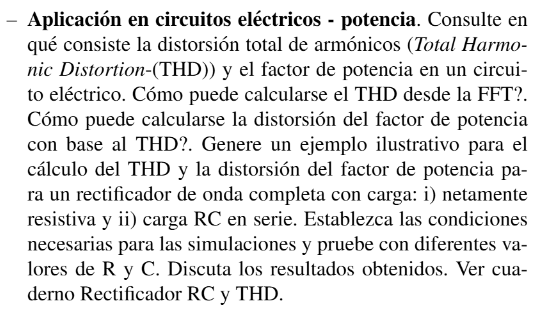

# Simulación circuito rectificador de onda completa RC

Para circuito RC serie, la salida (voltaje en el capacitor) se puede calcular utilizando impedancias transformadas, como:

$V_c(s) =V_{in}(s) \frac{1}{RCs + 1}$

- Se reemplazará la entrada por una aproximación numérica de una onda cosenoidal rectificada.

Para una carga netamente resistiva se asume:
$C=0$

In [11]:
#paquetes de para simulación
import numpy as np
import scipy
import matplotlib.pyplot as plt
#%matplotlib inline
import scipy.signal as sig
import scipy.optimize as opt
#from IPython.display import Image
import sympy as sym
#sym.init_session()

Funcion de transferencia

In [12]:
s = sym.symbols('s', complex=True)
t, R, L, C = sym.symbols('t R L C', positive=True)
X = sym.Function('X')(s)

Y = 1/(R*C*s + 1) * X
Y

X(s)/(C*R*s + 1)

Valores de R y C

In [13]:
R_v = 1000 #valores de simulacion de R
C_v =  10e-6 # valores de simulacion de C
Y_RC = Y.subs(R, R_v).subs(C, C_v)
Y_RC

X(s)/(0.01*s + 1)

Fun. transferencia en scipy

In [14]:
num = np.array([1]) #coeficientes del numerador de la funcion de transferencia como numpy array
den = np.array([R_v*C_v,1])#coeficientes del denominador de la funcion de transferencia como numpy array
G_n = sig.TransferFunction(num, den) #funcion de transferencia en
print(num)
print(den)

[1]
[0.01 1.  ]


Entrada

In [15]:
Fo = 60 #frec alimentación
Fs = 30*Fo #frecuencia muestreo
To = 1/Fo #periodo fundamental
Ts = 1/Fs #periodo muestreo
t = np.arange(0, 5*To,Ts) # se simulan 5 peridos de alimentación con un muestreo segun Ts
A = 120 #amplitud entrada
#función de entrada aproximada como onda senoidal rectificada completa
in_o = A*(np.sin(2*np.pi*Fo*t))
rec_c = sig.square(2*np.pi*Fo*t)#función tren de pulsos para simular señal rectificada
#Para rectificador de media onda:
rec_m = 0.5*(sig.square(2*np.pi*Fo*t)+1)
in_ = in_o * rec_c #si se quiere probar con rec media onda multiplicar por rec_m
out = G_n.output(in_, T=t)[1] #evaluar salida ante entrada rectificada mediante aproximacion numérica de scipy

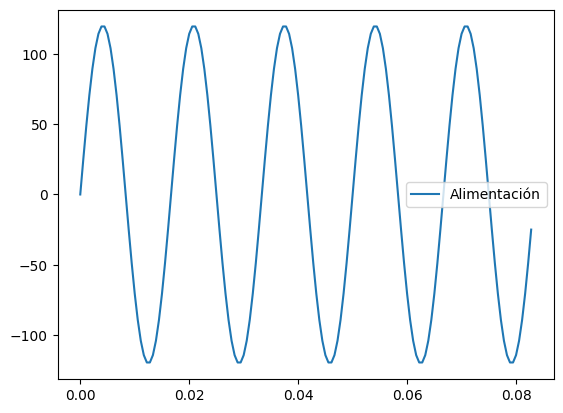

In [16]:
#señales de alimentación y tren de pulsos
plt.plot(t,in_o,label='Alimentación')
plt.legend()
plt.show()

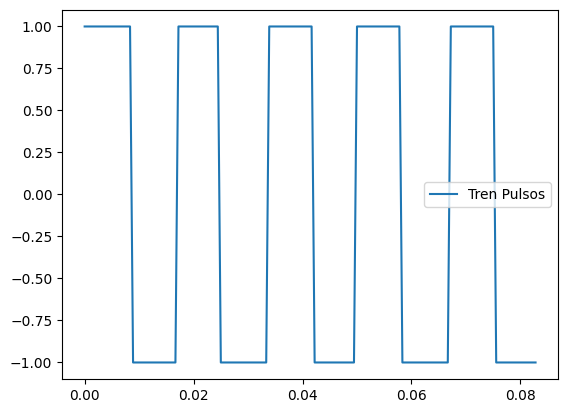

In [17]:
plt.plot(t,rec_c,label='Tren Pulsos')
plt.legend()
plt.show()

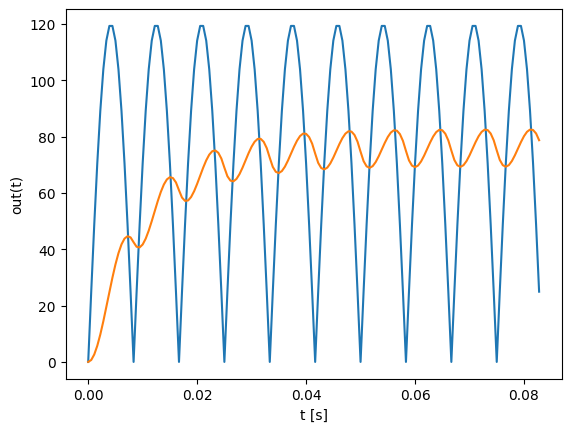

In [18]:
plt.plot(t, in_,label='In(t)')#entrada rectificada
plt.plot(t, out,label='Out(t)')#salida del circuito
plt.xlabel('t [s]')
plt.ylabel('out(t)')
plt.show()

Cálculo del espectro

Ingrese Im: 1


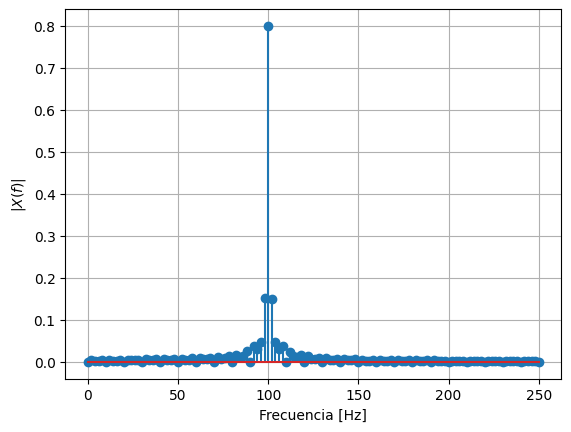

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
Fc = 100
Fm = 10
Am = 1
ti = 0
tf = 5 / Fm
Fs = 5 * Fc
t = np.arange(ti, tf, 1 / Fs)

m = np.zeros(len(t))
m[(t >= 0.1) & (t <= 0.4)] = Am

Im = float(input("Ingrese Im: "))
Ac = max(abs(m)) / Im
c = Ac * np.sin(2 * np.pi * Fc * t)

s = (1 + m / Ac) * c  # Señal AM
out = s  # salida a analizar con FFT

# FFT
vfre = np.fft.rfftfreq(len(out), 1 / Fs)
Xf = np.fft.rfft(out)

# Gráfica
plt.stem(vfre, abs(Xf) / len(out))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('$|X(f)|$')
plt.grid()
plt.show()


# Cálculo de la distorsión total de armónicos - THD

Se calcula como:

$$THD = \frac{\sqrt{V_2+V_3+\cdots V_n}}{V_1}$$

donde $V_n$ es el valor del $n$-th armónico de la señal de salida del circuito (en términos de tensión) y $V_1$ es la componente (armónico fundamental).

La medida de distorsión del factor de potencia se calcula como:

$$PF_{THD}=\sqrt{\frac{1}{1+(THD)^2}}$$

In [24]:
def calculate_thd(Xf, vfre, fundamental_freq):
    V1 = abs(Xf[vfre == fundamental_freq][0])  # Frecuencia fundamental
    Vn = np.sqrt(np.sum(abs(Xf[(vfre != 0) & (vfre != fundamental_freq)])**2))  # Todos los armónicos adicionales
    THD = (Vn / V1) * 100  # THD en porcentaje
    return THD
thd_CR = calculate_thd(Xf, vfre, 2*Fo)
print(f"THD de la señal con carga resistiva: {thd_CR:.4f}%")

THD de la señal con carga resistiva: 117646555227790720.0000%


In [25]:
pf=np.sqrt(1/(1+(thd_CR/100)**2))
print(f"El factor de potencia de la señal con carga RC: {pf:.4f}")

El factor de potencia de la señal con carga RC: 0.0000
